# Cooperation dynamics of LLM agents — source of truth

**Branch `donors-game-dynamics`, package `llm_dynamics/`.** This notebook is
regenerated by `llm_dynamics/build_notebook.py`; every table and figure below is
read from `llm_dynamics/results/` at execution time, so it always reflects the
latest runs. Narrative sections record the *decisions* (design, mappings,
deviations, caveats); code cells record the *evidence*.

## 0. What we are doing, in one paragraph

MARL-mixed studies the **dynamics of cooperation** — not just whether agents end up
cooperating, but the vector field of learning that carries them there — using
CRLD flow fields (pyCRLD) and, for learners without a closed-form flow (deep RL),
measured trajectories overlaid on the analytic flow of the reduced matrix game.
donorSim (branch `neurips-methodology`) trains LLMs with RL (verl GRPO; reward =
normalized donors-game payoff + HKB coordination term + CFE group term) on a
dyadic donors game against scripted strategies, and claims the training
**changes the LLM's dynamics**. Here we make that claim measurable: the same
phase portraits, with an LLM in the learner's seat — first the **base model**
(this notebook), then the RL-trained checkpoint on the same axes.


## 1. Background we build on

### 1.1 MARL-mixed methodology (this repo)
* State of the system = joint policy $X_i(a\mid s)$. A flow plot is a 2-D slice
  (agent-0 $P(C)$ vs agent-1 $P(C)$ in a chosen memory state); arrows are the
  deterministic CRLD learning step $\Delta X = \mathrm{step}(X)-X$
  (`pyCRLD.Utils.FlowPlot.plot_strategy_flow`, `use_RPEarrows=False`), with
  off-slice coordinates marginalized by Latin-hypercube sampling.
* Memory-$m$ games via `HistoryEmbedded(env, h=(m,)*(N+1))`, state count $(2^N)^m$.
* Observability regimes = row-stochastic observation-aliasing matrices
  (`scratch_repro/mem_obs_grids.py`: full / self / others / coop / def / blind).
* Learners with no analytic flow (JaxMARL deep RL, `jaxmarl_env/algo_phase.py`):
  grey CRLD arrows as theory, coloured measured paths as reality, **the deviation
  is the finding**.
* Paper findings we lean on: self-observability is load-bearing; memory enlarges
  the cooperative basin (memory-1 flow drains to defection, memory-2 has a (1,1)
  attractor); actor-critic is bistable, SARSA converges to an interior point.

### 1.2 donorSim `neurips-methodology`
* **Basic dyadic scenario** = the `direct_indirect` training rollout
  (`donor_sim/verl_integration/donor_game_interaction.py` +
  `donor_sim/game_helpers.py`): one LLM vs one scripted partner drawn from
  `OPPONENT_POOL` = {AllC .15, AllD .30, TFT .20, TF2T .20, Random .10, Grim .05};
  $b\sim U[3,6]$, $c/b\sim U[0.1,1.5]$, $w,q\in\{0,.25,.5,.75,1\}$, 3–8 rounds.
* Semantics: simultaneous moves ("If you COOPERATE: you receive 0, partner
  receives $b$; if you DEFECT: you receive $c$"); partner reacts to the model's
  *prior* rounds; **$w$** = probability the same partner returns next round
  (else a stranger arrives, per-partner history wiped); **$q$** = probability a
  reputation report about the partner is available.
* Training: verl GRPO (LoRA r=16, KL 0.001, 8 generations, per-turn credit),
  reward $r = \frac{\pi + c}{b+c} + \lambda_{tom}[4q\cos\phi + \tfrac{c}{b}\cos 2\phi] - \lambda_g\,\mathrm{CFE}$
  with HKB phase $\phi$ from a window-4 coordination signal; phase transition at
  $q = c/b$ (Nowak's indirect-reciprocity threshold). Released run on Qwen3-8B;
  a Qwen3-32B methodology checkpoint (`step_175`) exists.
* Eval stack already reads a continuous $p_{coop}$ from decision-token logprobs
  (`metastability_eval/harness/vllm_client.py`); branch `metastability-eval`
  holds the drift/dwell/Markov analyses.


## 2. The theory mapping: donors game → CRLD

| donorSim | CRLD (`llm_dynamics/donors_crld.py`) |
|---|---|
| payoffs $(b,c)$, both players donors | donation-game PD $(R,T,S,P)=(b-c,\;b,\;-c,\;0)$; on the training's normalized scale $\big(\tfrac{b}{b+c},1,0,\tfrac{c}{b+c}\big)$ (default) |
| $w$ — re-encounter probability | discount factor $\gamma=w$ (clamped to 0.99). Continuation probability *is* the discount factor of the repeated game; Nowak's $w>c/b$ is the discounted-game threshold |
| $q$ — reputation availability | observability blend $O = q\,O_{\text{full}} + (1-q)\,O_{\text{self}}$ — the partner's action is visible w.p. $q$, else only one's own |
| per-partner memory | `HistoryEmbedded(env, h=(m,m,m))` |
| set-strategy opponent | pinned policy $X_{opp}[s,a]$ (AllC/AllD/TFT/TF2T/Grim-$m$/WSLS, $\epsilon$-mixed); the learner's seat gets a **fixed-opponent flow field** |

Two backgrounds are therefore available for every $(b,c,w,q,m)$:
1. **two-agent CRLD flow** (both seats learning) in the *cooperation plane*
   $(P_{model}(C),\,P_{partner}(C))$ — the repo convention;
2. **fixed-opponent flow** in the *reciprocity plane*
   $\big(P(C\mid\text{sustained mutual }C),\;P(C\mid\text{own }C,\text{ partner }D)\big)$ —
   the theoretically matched background for "set strategy vs LLM".


In [1]:
# Live: the CRLD flow of the donors game at the sweep's parameters, both backgrounds.
import os, sys, json, glob, numpy as np, pandas as pd, matplotlib.pyplot as plt
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd())=='llm_dynamics' else os.getcwd()
sys.path.insert(0, ROOT); os.chdir(ROOT)
from llm_dynamics import donors_crld as dc, plots
from pyCRLD.Utils import FlowPlot as fp
b, c, w, q, m = 4.0, 2.0, 0.75, 0.75, 1
memo = dc.donors_memo_env(b, c, memory=m, q=q); mae = dc.build_mae(memo, w=w, q=q)
fig, axs = plt.subplots(1, 2, figsize=(10, 4.6))
plots.crld_flow_background(axs[0], mae, dc.allc_state(memo))
axs[0].set_title(f'two-agent CRLD flow (b={b:g}, c/b={c/b:g}, γ=w={w}, q={q}, memory {m})', fontsize=9)
axs[0].set_xlabel('agent 0 P(C)'); axs[0].set_ylabel('agent 1 P(C)')
X_opp = dc.strategy_policy('tit_for_tat', memo)
XX, YY, dX, dY = dc.fixed_opponent_flow(mae, memo, X_opp, dc.uniform_state(memo,'c','c',m), dc.uniform_state(memo,'c','d',m), NrRandom=6)
mdx, mdy = dX.mean(-1), dY.mean(-1); L = np.sqrt(mdx**2+mdy**2)+1e-12
axs[1].quiver(XX, YY, mdx*np.sqrt(L)/L, mdy*np.sqrt(L)/L, color='0.6', angles='xy')
axs[1].set_title('fixed-opponent flow vs TFT (reciprocity plane)', fontsize=9)
axs[1].set_xlabel('P(C | sustained mutual C)'); axs[1].set_ylabel('P(C | own C, partner D)')
for a in axs: a.set_xlim(-.03,1.03); a.set_ylim(-.03,1.03)
plt.tight_layout(); plt.show()

## 3. How the LLM is measured

* **Order parameter.** `p_cooperate` = renormalized COOPERATE-mass vs DEFECT-mass
  in the top-20 logprobs at the token after the *last* `DECISION:` marker
  (`llm_client.decision_probability`). It reads the distribution the sampler
  drew from; decoding is unchanged. Because the model writes a rationale before
  `DECISION:` (sampled at $T=0.6$), a single call's $p$ is near-binary — the
  stochasticity lives in the rationale — so means over seeds/rounds are needed.
* **Probes** (`policy_probe.py`): render the exact prompt for every memory-$m$
  history state ($4^m$ states) and read $p$ greedily → the LLM as a point
  $X[s]$ in CRLD policy space. Donors framing = conversational replay with forced
  `DECISION:` assistant turns; matrix framing = the stateless memory-$m$ prompt.
* **Play** (`donors_game.py`, `matrix_games.py`): full games vs a fixed
  strategy, per-round JSONL (`model_action`, `opp_action`, `p_cooperate`, HKB
  $\phi$, payoffs on both scales, swap events, visible state).
* **Portraits** (`plots.py`): cooperation-plane paths (sliding window 8) over the
  two-agent flow; reciprocity-plane stars (probes) + paths (windowed conditional
  frequencies) over the fixed-opponent flow; $q\times w$ heatmaps with the
  $q=c/b$ line.
* **Optimality gaps** (`analysis.py`), two optima by dynamic programming over
  the fixed strategy's state machine, per partner segment (swaps wipe the
  opponent's memory), same horizon:
  - **best-response captured** = model payoff ÷ the max payoff an oracle could
    extract from that strategy ("against AllD the model should AllD" ⇔ 1.0);
  - **welfare captured** = joint payoff ÷ the max joint (model + partner) payoff
    reachable against that strategy — the utilitarian point of the Pareto
    frontier the model controls (mutual cooperation vs TFT/AllC). The two
    disagree exactly where reciprocity and altruism disagree: vs AllD the
    welfare optimum is to be exploited (joint 6/round vs 4), so a perfect
    reciprocator scores BR 1.00 / welfare 0.67.

### 3.0 Opponent strategies (all nine)

| strategy | rule | reference behaviour |
|---|---|---|
| AllC | C every round | all C |
| AllD | D every round | all D (all C in Chicken / Harmony, where $S>P$) |
| TFT | opens C, mirrors your last move | all C |
| TF2T | opens C, defects after two consecutive D | all C |
| Grim | C until your first D, then D forever | all C |
| Random | C/D with prob ½ | D |
| suspicious TFT | opens **D**, then mirrors | all C |
| WSLS (Pavlov) | repeat if you cooperated, switch if you defected | all C |
| generous TFT | TFT, forgives a D with prob 0.3 | all C |

The first six are donorSim's training pool (`OPPONENT_POOL`); the last three
are added here. Each is also a pinned CRLD policy (fixed-opponent flows) and a
finite-state machine for the dynamic programs.

### 3.1 Fidelity to the training environment (deliberate choices)
* Donors prompts are byte-faithful to the `direct_indirect` rollout (rules,
  $w$/$q$ phrasing, $q$-gated reputation report, `/no_think`, round-result
  turns, swap text). Strategies, payoffs, HKB, parsing are vendored verbatim
  (`strategies.py`, from `game_helpers.py` @ merge-base `e665f87`).
* **Deviation:** `--swap-mode same` — a successor partner keeps the *same*
  strategy so the dyad stays strategy-controlled (`pool` reproduces training).
* **Addition:** `suspicious_tit_for_tat` (opens D, then mirrors) — not in the
  training pool; used so that half of the TFT games open with D.
* **Addition:** an LLM memory window for the donors framing (`--memories`):
  the rules prompt + only the last $m$ (assistant, round-result) turn pairs.
  `full` is the training setting.
* Matrix games are **stateless** per round with an explicit last-$m$ history
  block, so the LLM is genuinely a memory-$m$ policy on exactly the CRLD state
  space. Payoffs: PD (3,5,0,1), Chicken (3,5,1,0), Stag Hunt (5,3,0,1),
  Harmony (5,3,2,0) as $(R,T,S,P)$.
* Qwen3 thinking mode is **off** (`enable_thinking=False` + `/no_think`), the
  stage-1 training setting. Temperature 0.6 for play, 0 for probes.

### 3.2 Compute rule
**Everything GPU runs through SLURM** (`llm_dynamics/slurm/*.sbatch`), never on
`rnn`. Server: `serve_qwen32b.sbatch` (vllm-env, one A100-80GB, writes
`logs/vllm_endpoint.txt` + `.ready`). Clients are CPU jobs that wait on the
sentinel. `llm_dynamics/README.md` has the commands.


## 4. Experiment registry (base model = `Qwen/Qwen3-32B`, the pre-RL checkpoint)

| id | SLURM jobs | design | outputs |
|---|---|---|---|
| **v1** | server 1183776 / client 1183777 (2026-08-25, 1h13m) | donors: {TFT, AllD, AllC} × q,w ∈ {0,.5,1}, b=4, c/b=.5, 2 seeds × 20 rounds, full memory; probes m1 at 4 (w,q) corners + m2; matrix: 4 games × m ∈ {1,2} × {TFT, AllD} × 1 seed × 20 rounds; matrix probes m1,m2 | `results/qwen32b_base_donors_sweep/`, `results/qwen32b_base_matrix_sweep/`, `results/probes/qwen32b_base_*`, `results/qwen32b_base_reciprocity_tft.png` |
| **v2** | server 1183852 / clients 1183853 + supplementary (2026-08-25) | donors: **all 9 strategies** {TFT, suspicious TFT, AllC, AllD, TF2T, Grim, Random, WSLS, generous TFT} × q,w ∈ {0,.5,1} × LLM memory {full,1,2,4} × 2 seeds × 20 rounds; matrix: same 9 strategies × 4 games × m ∈ {1,2,3,4,6} × 2 seeds; probes to m=3 both framings | `results/qwen32b_base_donors_v2/<strategy>/`, `results/qwen32b_base_matrix_v2/<strategy>/`, `results/qwen32b_base_v2_tables.md` |
| offline | — | `demo`: mock base-selfish vs mock trained-reciprocal through the identical code path | `results/demo_*` |

Memory ceiling: CRLD backgrounds stop at $m=3$ ($4^m$ states; `MAX_CRLD_MEMORY`);
the LLM prompt window is cheap and is swept to $m=6$ (probes to $m=3$: 64 calls
per framing; $m=4$ would be 256).


## 5. Results — base Qwen3-32B

### 5.1 Probed conditional policy (donors framing)

In [2]:
def show_probes(pattern):
    rows = []
    for f in sorted(glob.glob(pattern)):
        p = json.load(open(f)); name = os.path.basename(f).replace('.json','')
        row = {'probe': name}
        row.update({k: v['p_cooperate'] for k, v in sorted(p['states'].items())})
        rows.append(row)
    return pd.DataFrame(rows).set_index('probe').round(2) if rows else 'pending'
display(show_probes('llm_dynamics/results/probes/qwen32b_base_donors_m1_*.json'))
display(show_probes('llm_dynamics/results/probes/qwen32b_base_donors_m2_*.json').T)

,cc,cd,dc,dd
probe,,,,
qwen32b_base_donors_m1_w0.25_q0.25,1.0,0.0,0.0,0.99
qwen32b_base_donors_m1_w0.25_q0.75,1.0,0.0,1.0,0.29
qwen32b_base_donors_m1_w0.75_q0.25,1.0,0.0,1.0,0.00
qwen32b_base_donors_m1_w0.75_q0.75,1.0,0.0,1.0,1.00


probe,qwen32b_base_donors_m2_w0.75_q0.75
cc|cc,1.00
cc|cd,0.00
cc|dc,0.98
cc|dd,0.97
cd|cc,1.00
cd|cd,0.88
cd|dc,0.94
cd|dd,0.73
dc|cc,1.00
dc|cd,0.00


State labels are `own/partner` initials, oldest → newest. Reading: `cc`=after
mutual cooperation, `cd`=after being suckered, `dc`=after exploiting, `dd`=after
mutual defection.

### 5.2 Matrix-game probes (memory 1–3)

In [3]:
for g in ['ipd','chicken','staghunt','harmony']:
    print(g); display(show_probes(f'llm_dynamics/results/probes/qwen32b_base_{g}_m1.json'))
display(show_probes('llm_dynamics/results/probes/qwen32b_base_*_m2.json').T)

ipd


,cc,cd,dc,dd
probe,,,,
qwen32b_base_ipd_m1,1.0,0.0,1.0,1.0


chicken


,cc,cd,dc,dd
probe,,,,
qwen32b_base_chicken_m1,1.0,0.0,1.0,1.0


staghunt


,cc,cd,dc,dd
probe,,,,
qwen32b_base_staghunt_m1,1.0,0.0,1.0,1.0


harmony


,cc,cd,dc,dd
probe,,,,
qwen32b_base_harmony_m1,1.0,0.0,1.0,1.0


probe,qwen32b_base_chicken_m2,qwen32b_base_harmony_m2,qwen32b_base_ipd_m2,qwen32b_base_staghunt_m2
cc|cc,1.0,1.0,1.0,1.0
cc|cd,0.0,0.0,0.0,0.0
cc|dc,1.0,1.0,1.0,1.0
cc|dd,1.0,1.0,1.0,0.0
cd|cc,0.0,0.0,1.0,1.0
cd|cd,0.0,0.0,0.0,0.0
cd|dc,1.0,1.0,0.0,0.0
cd|dd,0.0,0.0,0.0,0.0
dc|cc,1.0,1.0,1.0,1.0
dc|cd,1.0,1.0,0.0,0.0


### 5.3 v1 sweep — cooperation rate and best-response regret

In [4]:
from llm_dynamics import analysis
for d in ['llm_dynamics/results/qwen32b_base_donors_sweep', 'llm_dynamics/results/qwen32b_base_matrix_sweep']:
    if os.path.isdir(d):
        t = analysis.regret_table(d)
        df = pd.DataFrame([{**{'cell': ' '.join(k)}, **{kk: vv for kk, vv in v.items() if kk!='n'}} for k, v in t.items()]).set_index('cell')
        display(df.round(2))

,model,best_response,allc,alld,captured,regret_per_round,joint,social_optimum,welfare_captured,coop,br_coop,social_coop,reference,reference_captured,agreement,reference_action,br_seq
cell,,,,,,,,,,,,,,,,,
always_cooperate q=0 w=0 full,100.0,120.0,80.0,120.0,0.83,1.00,140.0,160.0,0.88,0.50,0.00,1.0,80.0,1.25,0.50,COOPERATE,D
always_cooperate q=0 w=0.5 full,81.0,120.0,80.0,120.0,0.68,1.95,159.0,160.0,0.99,0.98,0.00,1.0,80.0,1.01,0.98,COOPERATE,D
always_cooperate q=0 w=1 full,80.0,120.0,80.0,120.0,0.67,2.00,160.0,160.0,1.00,1.00,0.00,1.0,80.0,1.00,1.00,COOPERATE,DDDDDDDDDDDDDDDDDDDD
always_cooperate q=0.5 w=0 full,100.0,120.0,80.0,120.0,0.83,1.00,140.0,160.0,0.88,0.50,0.00,1.0,80.0,1.25,0.50,COOPERATE,D
always_cooperate q=0.5 w=0.5 full,80.0,120.0,80.0,120.0,0.67,2.00,160.0,160.0,1.00,1.00,0.00,1.0,80.0,1.00,1.00,COOPERATE,D
always_cooperate q=0.5 w=1 full,80.0,120.0,80.0,120.0,0.67,2.00,160.0,160.0,1.00,1.00,0.00,1.0,80.0,1.00,1.00,COOPERATE,DDDDDDDDDDDDDDDDDDDD
always_cooperate q=1 w=0 full,80.0,120.0,80.0,120.0,0.67,2.00,160.0,160.0,1.00,1.00,0.00,1.0,80.0,1.00,1.00,COOPERATE,D
always_cooperate q=1 w=0.5 full,80.0,120.0,80.0,120.0,0.67,2.00,160.0,160.0,1.00,1.00,0.00,1.0,80.0,1.00,1.00,COOPERATE,DD
always_cooperate q=1 w=1 full,80.0,120.0,80.0,120.0,0.67,2.00,160.0,160.0,1.00,1.00,0.00,1.0,80.0,1.00,1.00,COOPERATE,DDDDDDDDDDDDDDDDDDDD


,model,best_response,allc,alld,captured,regret_per_round,joint,social_optimum,welfare_captured,coop,br_coop,social_coop,reference,reference_captured,agreement,reference_action,br_seq
cell,,,,,,,,,,,,,,,,,
always_defect chicken m1,7.0,20.0,20.0,0.0,0.35,0.65,42.0,120.0,0.35,0.35,1.00,1.0,20.0,0.35,0.35,COOPERATE,CCCCCCCCCCCCCCCCCCCC
always_defect chicken m2,5.0,20.0,20.0,0.0,0.25,0.75,30.0,120.0,0.25,0.25,1.00,1.0,20.0,0.25,0.25,COOPERATE,CCCCCCCCCCCCCCCCCCCC
always_defect harmony m1,18.0,40.0,40.0,0.0,0.45,1.10,45.0,100.0,0.45,0.45,1.00,1.0,40.0,0.45,0.45,COOPERATE,CCCCCCCCCCCCCCCCCCCC
always_defect harmony m2,12.0,40.0,40.0,0.0,0.30,1.40,30.0,100.0,0.30,0.30,1.00,1.0,40.0,0.30,0.30,COOPERATE,CCCCCCCCCCCCCCCCCCCC
always_defect ipd m1,14.0,20.0,0.0,20.0,0.70,0.30,58.0,100.0,0.58,0.30,0.00,1.0,20.0,0.70,0.70,DEFECT,DDDDDDDDDDDDDDDDDDDD
always_defect ipd m2,15.0,20.0,0.0,20.0,0.75,0.25,55.0,100.0,0.55,0.25,0.00,1.0,20.0,0.75,0.75,DEFECT,DDDDDDDDDDDDDDDDDDDD
always_defect staghunt m1,13.0,20.0,0.0,20.0,0.65,0.35,47.0,60.0,0.78,0.35,0.00,1.0,20.0,0.65,0.65,DEFECT,DDDDDDDDDDDDDDDDDDDD
always_defect staghunt m2,16.0,20.0,0.0,20.0,0.80,0.20,44.0,60.0,0.73,0.20,0.00,1.0,20.0,0.80,0.80,DEFECT,DDDDDDDDDDDDDDDDDDDD
tit_for_tat chicken m1,62.0,62.0,60.0,5.0,1.00,0.00,120.0,120.0,1.00,0.95,0.95,1.0,60.0,1.03,0.95,COOPERATE,CCCCCCCCCCCCCCCCCCCD


llm_dynamics/results/qwen32b_base_reciprocity_tft.png


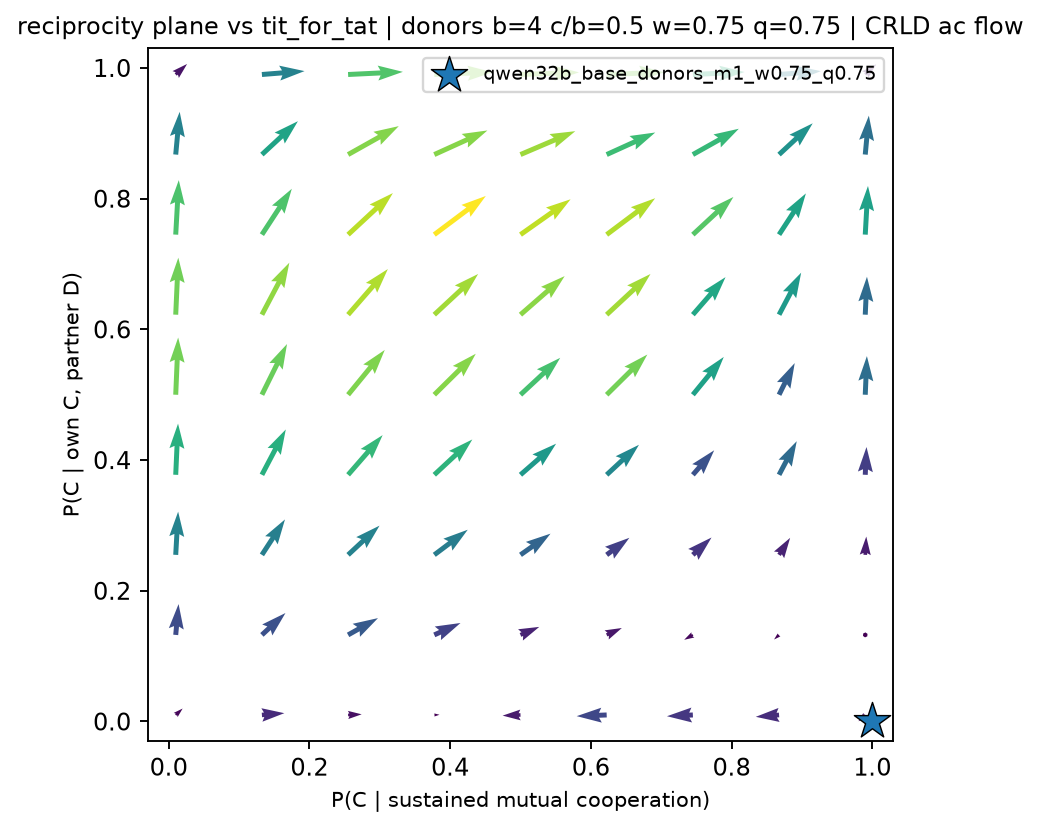

llm_dynamics/results/qwen32b_base_donors_sweep/heatmap_qwen3-32b-base_tit_for_tat.png


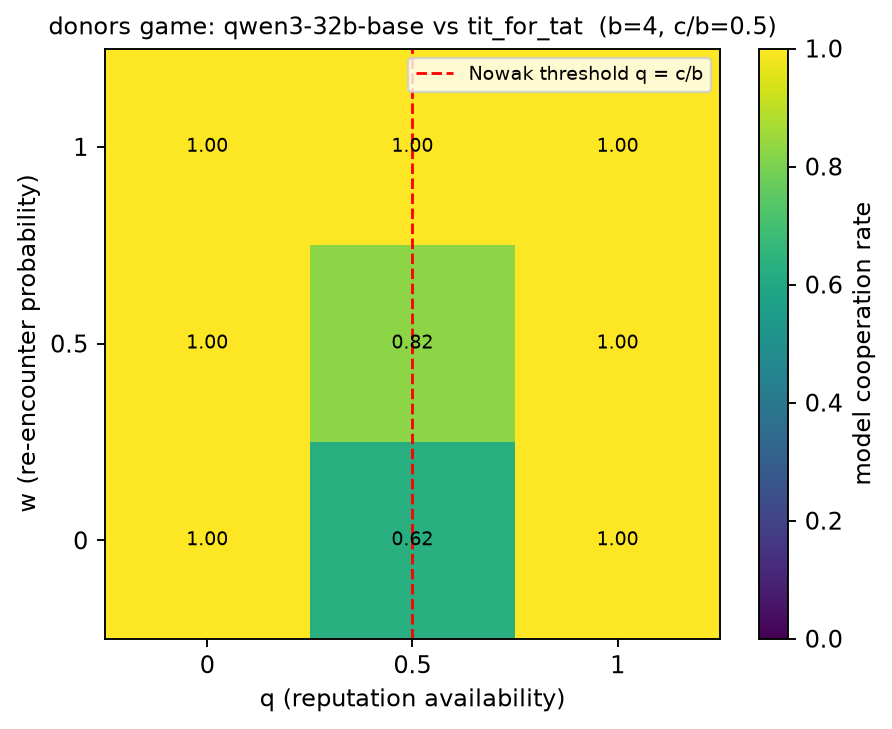

llm_dynamics/results/qwen32b_base_donors_sweep/heatmap_qwen3-32b-base_always_defect.png


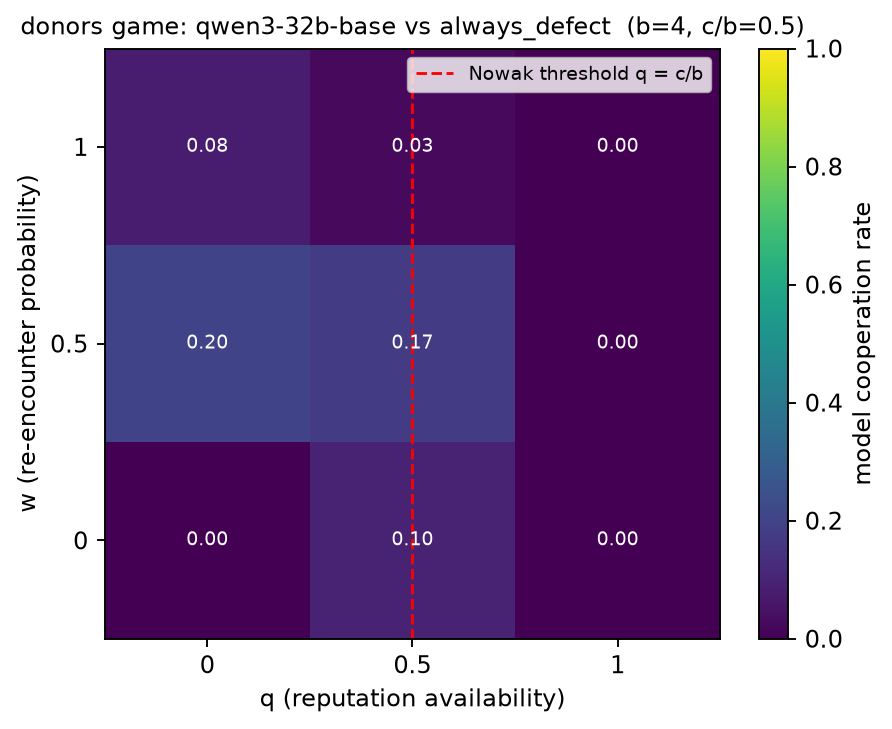

In [5]:
from IPython.display import Image, display as _d
for f in ['llm_dynamics/results/qwen32b_base_reciprocity_tft.png',
          'llm_dynamics/results/qwen32b_base_donors_sweep/heatmap_qwen3-32b-base_tit_for_tat.png',
          'llm_dynamics/results/qwen32b_base_donors_sweep/heatmap_qwen3-32b-base_always_defect.png']:
    if os.path.exists(f): print(f); _d(Image(f, width=480))

### 5.4 v2 — strategies (incl. suspicious TFT) × (w,q) × memory, and × games × memory

Each cell is **agreement with the reference policy · model payoff / reference
payoff · best-response captured · welfare captured**. The *reference policy*
is the normative "match the partner" behaviour: all-C against AllC and against
every conditional cooperator (TFT, suspicious TFT, TF2T, Grim — vs Grim one
defection triggers permanent defection, so all-C dominates all-D), all-D
against AllD in the donors game / PD / Stag Hunt, and all-C against AllD in
Chicken / Harmony (there $S>P$: swerving beats crashing). The two DP optima (best response = max own payoff; welfare = max
joint payoff) are kept as bounds: the reference equals the welfare optimum vs
cooperators and the best response vs AllD.

**Unknown-partner view.** Those per-strategy yardsticks assume the partner is
known, so an opening/probing cooperation against AllD counts as a loss. The
last tables instead average the model's payoff over the strategy pool and
compare it with (a) the best *blind* meta-policy — one fixed rule (all-C,
all-D, TFT, TFT-with-last-round-D, probe-once, Grim, Pavlov) played without
knowing the partner, under an equal prior and under donorSim's training-pool
prior — and (b) the informed optimum (sum of best responses). Probing is
worth it exactly when (a) is a cooperative opener, and the model's gap to (a)
is the uncertainty-aware regret.
(Reads `results/qwen32b_base_v2_tables.md`; shows *pending* until job 1183853 finishes.)

In [6]:
from IPython.display import Markdown
f = 'llm_dynamics/results/qwen32b_base_v2_tables.md'
display(Markdown(open(f).read()) if os.path.exists(f) else Markdown('**v2 tables pending** (SLURM job 1183853)'))


### Donors game — LLM memory full  (cell = agreement with reference · model/reference payoff · BR captured · welfare captured; reference = all-C vs AllC and conditional cooperators, stage-game best response vs AllD)

| vs | w=0 q=0 | w=0 q=0.5 | w=0 q=1 | w=0.5 q=0 | w=0.5 q=0.5 | w=0.5 q=1 | w=1 q=0 | w=1 q=0.5 | w=1 q=1 |
|---|---|---|---|---|---|---|---|---|---|
| always_cooperate | 0.50 · 100/80 · 0.83 · 0.88 | 0.90 · 84/80 · 0.70 · 0.97 | 1.00 · 80/80 · 0.67 · 1.00 | 0.53 · 99/80 · 0.82 · 0.88 | 1.00 · 80/80 · 0.67 · 1.00 | 1.00 · 80/80 · 0.67 · 1.00 | 1.00 · 80/80 · 0.67 · 1.00 | 1.00 · 80/80 · 0.67 · 1.00 | 1.00 · 80/80 · 0.67 · 1.00 |
| always_defect | 0.90 · 36/40 · 0.90 · 0.70 | 0.97 · 39/40 · 0.97 · 0.68 | 1.00 · 40/40 · 1.00 · 0.67 | 0.70 · 28/40 · 0.70 · 0.77 | 0.93 · 37/40 · 0.93 · 0.69 | 1.00 · 40/40 · 1.00 · 0.67 | 0.93 · 37/40 · 0.93 · 0.69 | 0.97 · 39/40 · 0.97 · 0.68 | 0.97 · 39/40 · 0.97 · 0.68 |
| generous_tit_for_tat | 0.07 · 117/80 · 0.97 · 0.77 | 0.20 · 112/80 · 0.93 · 0.80 | 0.47 · 101/80 · 0.84 · 0.87 | 0.72 · 83/80 · 0.82 · 0.91 | 0.55 · 86/80 · 0.81 · 0.85 | 0.68 · 89/80 · 0.83 · 0.91 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 |
| grim_trigger | 0.00 · 120/80 · 1.00 · 0.75 | 0.95 · 82/80 · 0.68 · 0.99 | 1.00 · 80/80 · 0.67 · 1.00 | 1.00 · 80/80 · 0.78 · 1.00 | 0.95 · 82/80 · 0.76 · 0.99 | 0.70 · 82/80 · 0.80 · 0.89 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 |
| random | 0.47 · 59/80 · 0.74 · 0.86 | 0.85 · 70/80 · 0.88 · 0.74 | 0.65 · 60/80 · 0.75 · 0.79 | 0.28 · 51/80 · 0.64 · 0.92 | 0.60 · 62/80 · 0.77 · 0.82 | 0.50 · 54/80 · 0.68 · 0.84 | 0.43 · 57/80 · 0.71 · 0.88 | 0.55 · 52/80 · 0.65 · 0.81 | 0.65 · 56/80 · 0.70 · 0.78 |
| suspicious_tit_for_tat | 0.08 · 37/0 · 0.93 · 0.69 | 0.20 · 32/0 · 0.80 · 0.73 | 0.30 · 28/0 · 0.70 · 0.77 | 0.40 · 40/34 · 0.70 · 0.76 | 0.20 · 38/24 · 0.73 · 0.69 | 0.28 · 41/36 · 0.71 · 0.70 | 0.42 · 57/76 · 0.73 · 0.72 | 0.47 · 59/76 · 0.76 · 0.75 | 0.35 · 54/76 · 0.69 · 0.68 |
| tit_for_tat | 0.55 · 98/80 · 0.82 · 0.89 | 0.57 · 97/80 · 0.81 · 0.89 | 1.00 · 80/80 · 0.67 · 1.00 | 0.55 · 80/80 · 0.78 · 0.83 | 1.00 · 80/80 · 0.74 · 1.00 | 1.00 · 80/80 · 0.78 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 |
| tit_for_two_tats | 0.03 · 119/80 · 0.99 · 0.76 | 0.38 · 105/80 · 0.88 · 0.84 | 1.00 · 80/80 · 0.67 · 1.00 | 1.00 · 80/80 · 0.70 · 1.00 | 1.00 · 80/80 · 0.68 · 1.00 | 1.00 · 80/80 · 0.70 · 1.00 | 1.00 · 80/80 · 0.78 · 1.00 | 1.00 · 80/80 · 0.78 · 1.00 | 1.00 · 80/80 · 0.78 · 1.00 |
| wsls | 0.50 · 100/80 · 0.83 · 0.88 | 0.12 · 115/80 · 0.96 · 0.78 | 0.17 · 113/80 · 0.94 · 0.79 | 0.15 · 94/80 · 0.91 · 0.73 | 0.78 · 83/80 · 0.77 · 0.93 | 0.33 · 89/80 · 0.87 · 0.78 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 |

### Donors game — LLM memory m1  (cell = agreement with reference · model/reference payoff · BR captured · welfare captured; reference = all-C vs AllC and conditional cooperators, stage-game best response vs AllD)

| vs | w=0 q=0 | w=0 q=0.5 | w=0 q=1 | w=0.5 q=0 | w=0.5 q=0.5 | w=0.5 q=1 | w=1 q=0 | w=1 q=0.5 | w=1 q=1 |
|---|---|---|---|---|---|---|---|---|---|
| always_cooperate | 0.38 · 105/80 · 0.88 · 0.84 | 0.62 · 95/80 · 0.79 · 0.91 | 1.00 · 80/80 · 0.67 · 1.00 | 0.93 · 83/80 · 0.69 · 0.98 | 0.88 · 85/80 · 0.71 · 0.97 | 1.00 · 80/80 · 0.67 · 1.00 | 1.00 · 80/80 · 0.67 · 1.00 | 1.00 · 80/80 · 0.67 · 1.00 | 1.00 · 80/80 · 0.67 · 1.00 |
| always_defect | 0.97 · 39/40 · 0.97 · 0.68 | 0.85 · 34/40 · 0.85 · 0.72 | 0.97 · 39/40 · 0.97 · 0.68 | 0.45 · 18/40 · 0.45 · 0.85 | 0.62 · 25/40 · 0.62 · 0.79 | 0.95 · 38/40 · 0.95 · 0.68 | 0.80 · 32/40 · 0.80 · 0.73 | 0.85 · 34/40 · 0.85 · 0.72 | 1.00 · 40/40 · 1.00 · 0.67 |
| generous_tit_for_tat | 0.40 · 104/80 · 0.87 · 0.85 | 0.35 · 106/80 · 0.88 · 0.84 | 0.50 · 100/80 · 0.83 · 0.88 | 0.88 · 85/80 · 0.83 · 0.97 | 0.80 · 82/80 · 0.76 · 0.93 | 0.73 · 83/80 · 0.81 · 0.91 | 0.97 · 81/80 · 0.99 · 0.99 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 |
| grim_trigger | 0.38 · 105/80 · 0.88 · 0.84 | 0.45 · 102/80 · 0.85 · 0.86 | 0.75 · 90/80 · 0.75 · 0.94 | 0.85 · 82/80 · 0.80 · 0.95 | 0.88 · 85/80 · 0.79 · 0.97 | 0.80 · 78/80 · 0.76 · 0.92 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 |
| random | 1.00 · 80/80 · 1.00 · 0.71 | 0.85 · 70/80 · 0.88 · 0.74 | 0.68 · 61/80 · 0.76 · 0.79 | 0.25 · 50/80 · 0.62 · 0.93 | 0.50 · 58/80 · 0.73 · 0.85 | 0.40 · 50/80 · 0.62 · 0.86 | 0.38 · 55/80 · 0.69 · 0.89 | 0.47 · 49/80 · 0.61 · 0.83 | 0.57 · 53/80 · 0.66 · 0.80 |
| suspicious_tit_for_tat | 0.28 · 29/0 · 0.72 · 0.76 | 0.32 · 27/0 · 0.68 · 0.78 | 0.38 · 25/0 · 0.62 · 0.79 | 0.62 · 39/34 · 0.68 · 0.85 | 0.55 · 34/24 · 0.66 · 0.83 | 0.53 · 39/36 · 0.67 · 0.80 | 0.50 · 60/76 · 0.77 · 0.76 | 0.47 · 59/76 · 0.76 · 0.75 | 0.38 · 55/76 · 0.71 · 0.70 |
| tit_for_tat | 0.12 · 115/80 · 0.96 · 0.78 | 0.65 · 94/80 · 0.78 · 0.91 | 0.97 · 81/80 · 0.68 · 0.99 | 0.88 · 85/80 · 0.83 · 0.97 | 0.88 · 83/80 · 0.77 · 0.96 | 0.97 · 81/80 · 0.79 · 0.99 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 |
| tit_for_two_tats | 0.03 · 119/80 · 0.99 · 0.76 | 0.60 · 96/80 · 0.80 · 0.90 | 1.00 · 80/80 · 0.67 · 1.00 | 0.90 · 84/80 · 0.73 · 0.97 | 0.90 · 84/80 · 0.71 · 0.98 | 0.95 · 82/80 · 0.71 · 0.99 | 0.97 · 81/80 · 0.79 · 0.99 | 1.00 · 80/80 · 0.78 · 1.00 | 1.00 · 80/80 · 0.78 · 1.00 |
| wsls | 0.03 · 119/80 · 0.99 · 0.76 | 0.40 · 104/80 · 0.87 · 0.85 | 0.33 · 107/80 · 0.89 · 0.83 | 0.88 · 83/80 · 0.81 · 0.96 | 0.72 · 83/80 · 0.77 · 0.91 | 0.48 · 85/80 · 0.83 · 0.82 | 0.97 · 81/80 · 0.99 · 0.99 | 1.00 · 80/80 · 0.98 · 1.00 | 0.97 · 81/80 · 0.99 · 0.99 |

### Donors game — LLM memory m2  (cell = agreement with reference · model/reference payoff · BR captured · welfare captured; reference = all-C vs AllC and conditional cooperators, stage-game best response vs AllD)

| vs | w=0 q=0 | w=0 q=0.5 | w=0 q=1 | w=0.5 q=0 | w=0.5 q=0.5 | w=0.5 q=1 | w=1 q=0 | w=1 q=0.5 | w=1 q=1 |
|---|---|---|---|---|---|---|---|---|---|
| always_cooperate | 0.03 · 119/80 · 0.99 · 0.76 | 0.68 · 93/80 · 0.78 · 0.92 | 1.00 · 80/80 · 0.67 · 1.00 | 0.17 · 113/80 · 0.94 · 0.79 | 0.72 · 91/80 · 0.76 · 0.93 | 1.00 · 80/80 · 0.67 · 1.00 | 1.00 · 80/80 · 0.67 · 1.00 | 1.00 · 80/80 · 0.67 · 1.00 | 1.00 · 80/80 · 0.67 · 1.00 |
| always_defect | 0.95 · 38/40 · 0.95 · 0.68 | 0.95 · 38/40 · 0.95 · 0.68 | 1.00 · 40/40 · 1.00 · 0.67 | 0.45 · 18/40 · 0.45 · 0.85 | 0.75 · 30/40 · 0.75 · 0.75 | 1.00 · 40/40 · 1.00 · 0.67 | 0.88 · 35/40 · 0.88 · 0.71 | 0.90 · 36/40 · 0.90 · 0.70 | 1.00 · 40/40 · 1.00 · 0.67 |
| generous_tit_for_tat | 0.50 · 100/80 · 0.83 · 0.88 | 0.25 · 110/80 · 0.92 · 0.81 | 0.55 · 98/80 · 0.82 · 0.89 | 0.30 · 92/80 · 0.89 · 0.78 | 0.65 · 88/80 · 0.81 · 0.89 | 0.62 · 87/80 · 0.84 · 0.88 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 |
| grim_trigger | 0.47 · 101/80 · 0.84 · 0.87 | 0.30 · 108/80 · 0.90 · 0.82 | 0.90 · 84/80 · 0.70 · 0.97 | 0.77 · 83/80 · 0.81 · 0.93 | 0.88 · 83/80 · 0.77 · 0.96 | 0.93 · 83/80 · 0.81 · 0.98 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 |
| random | 1.00 · 80/80 · 1.00 · 0.71 | 0.80 · 68/80 · 0.85 · 0.76 | 0.75 · 64/80 · 0.80 · 0.76 | 0.47 · 59/80 · 0.74 · 0.86 | 0.65 · 64/80 · 0.80 · 0.81 | 0.70 · 62/80 · 0.78 · 0.78 | 0.57 · 63/80 · 0.79 · 0.84 | 0.55 · 52/80 · 0.65 · 0.81 | 0.53 · 51/80 · 0.64 · 0.81 |
| suspicious_tit_for_tat | 0.10 · 36/0 · 0.90 · 0.70 | 0.28 · 29/0 · 0.73 · 0.76 | 0.32 · 27/0 · 0.68 · 0.78 | 0.65 · 38/34 · 0.66 · 0.86 | 0.38 · 37/24 · 0.71 · 0.77 | 0.22 · 39/36 · 0.67 · 0.67 | 0.22 · 49/76 · 0.63 · 0.62 | 0.38 · 53/76 · 0.68 · 0.69 | 0.47 · 59/76 · 0.76 · 0.75 |
| tit_for_tat | 0.50 · 100/80 · 0.83 · 0.88 | 0.95 · 82/80 · 0.68 · 0.99 | 1.00 · 80/80 · 0.67 · 1.00 | 0.80 · 82/80 · 0.80 · 0.93 | 0.90 · 84/80 · 0.78 · 0.97 | 1.00 · 80/80 · 0.78 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 |
| tit_for_two_tats | 0.50 · 100/80 · 0.83 · 0.88 | 0.90 · 84/80 · 0.70 · 0.97 | 1.00 · 80/80 · 0.67 · 1.00 | 0.85 · 86/80 · 0.75 · 0.96 | 0.85 · 86/80 · 0.73 · 0.96 | 0.97 · 81/80 · 0.70 · 0.99 | 1.00 · 80/80 · 0.78 · 1.00 | 1.00 · 80/80 · 0.78 · 1.00 | 1.00 · 80/80 · 0.78 · 1.00 |
| wsls | 0.50 · 100/80 · 0.83 · 0.88 | 0.25 · 110/80 · 0.92 · 0.81 | 0.22 · 111/80 · 0.93 · 0.81 | 0.45 · 88/80 · 0.86 · 0.82 | 0.53 · 87/80 · 0.81 · 0.84 | 0.50 · 86/80 · 0.84 · 0.83 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 |

### Donors game — LLM memory m4  (cell = agreement with reference · model/reference payoff · BR captured · welfare captured; reference = all-C vs AllC and conditional cooperators, stage-game best response vs AllD)

| vs | w=0 q=0 | w=0 q=0.5 | w=0 q=1 | w=0.5 q=0 | w=0.5 q=0.5 | w=0.5 q=1 | w=1 q=0 | w=1 q=0.5 | w=1 q=1 |
|---|---|---|---|---|---|---|---|---|---|
| always_cooperate | 1.00 · 80/80 · 0.67 · 1.00 | 0.97 · 81/80 · 0.68 · 0.99 | 1.00 · 80/80 · 0.67 · 1.00 | 0.53 · 99/80 · 0.82 · 0.88 | 1.00 · 80/80 · 0.67 · 1.00 | 1.00 · 80/80 · 0.67 · 1.00 | 1.00 · 80/80 · 0.67 · 1.00 | 1.00 · 80/80 · 0.67 · 1.00 | 1.00 · 80/80 · 0.67 · 1.00 |
| always_defect | 0.90 · 36/40 · 0.90 · 0.70 | 0.97 · 39/40 · 0.97 · 0.68 | 1.00 · 40/40 · 1.00 · 0.67 | 0.65 · 26/40 · 0.65 · 0.78 | 0.80 · 32/40 · 0.80 · 0.73 | 0.95 · 38/40 · 0.95 · 0.68 | 0.85 · 34/40 · 0.85 · 0.72 | 0.97 · 39/40 · 0.97 · 0.68 | 1.00 · 40/40 · 1.00 · 0.67 |
| generous_tit_for_tat | 1.00 · 80/80 · 0.67 · 1.00 | 0.53 · 99/80 · 0.82 · 0.88 | 0.38 · 105/80 · 0.88 · 0.84 | 0.95 · 82/80 · 0.80 · 0.99 | 0.32 · 91/80 · 0.85 · 0.78 | 0.43 · 95/80 · 0.86 · 0.83 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 |
| grim_trigger | 0.50 · 100/80 · 0.83 · 0.88 | 0.65 · 94/80 · 0.78 · 0.91 | 1.00 · 80/80 · 0.67 · 1.00 | 0.95 · 82/80 · 0.80 · 0.99 | 0.65 · 84/80 · 0.78 · 0.88 | 0.93 · 83/80 · 0.81 · 0.98 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 |
| random | 0.47 · 59/80 · 0.74 · 0.86 | 0.85 · 70/80 · 0.88 · 0.74 | 0.65 · 60/80 · 0.75 · 0.79 | 0.40 · 56/80 · 0.70 · 0.89 | 0.62 · 63/80 · 0.79 · 0.81 | 0.65 · 60/80 · 0.75 · 0.79 | 0.40 · 56/80 · 0.70 · 0.89 | 0.38 · 45/80 · 0.56 · 0.86 | 0.53 · 51/80 · 0.64 · 0.81 |
| suspicious_tit_for_tat | 0.08 · 37/0 · 0.93 · 0.69 | 0.30 · 28/0 · 0.70 · 0.77 | 0.45 · 22/0 · 0.55 · 0.82 | 0.33 · 41/34 · 0.72 · 0.73 | 0.38 · 27/24 · 0.52 · 0.73 | 0.33 · 39/36 · 0.67 · 0.72 | 0.45 · 58/76 · 0.74 · 0.73 | 0.35 · 54/76 · 0.69 · 0.68 | 0.35 · 54/76 · 0.69 · 0.68 |
| tit_for_tat | 1.00 · 80/80 · 0.67 · 1.00 | 0.70 · 92/80 · 0.77 · 0.93 | 0.95 · 82/80 · 0.68 · 0.99 | 0.97 · 81/80 · 0.79 · 0.99 | 1.00 · 80/80 · 0.74 · 1.00 | 0.97 · 79/80 · 0.77 · 0.99 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 |
| tit_for_two_tats | 1.00 · 80/80 · 0.67 · 1.00 | 0.72 · 91/80 · 0.76 · 0.93 | 0.95 · 82/80 · 0.68 · 0.99 | 0.95 · 82/80 · 0.71 · 0.99 | 1.00 · 80/80 · 0.68 · 1.00 | 0.90 · 84/80 · 0.73 · 0.97 | 1.00 · 80/80 · 0.78 · 1.00 | 1.00 · 80/80 · 0.78 · 1.00 | 1.00 · 80/80 · 0.78 · 1.00 |
| wsls | 1.00 · 80/80 · 0.67 · 1.00 | 0.22 · 111/80 · 0.93 · 0.81 | 0.17 · 113/80 · 0.94 · 0.79 | 0.97 · 81/80 · 0.79 · 0.99 | 0.75 · 86/80 · 0.80 · 0.93 | 0.53 · 81/80 · 0.79 · 0.82 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 | 1.00 · 80/80 · 0.98 · 1.00 |

### Matrix games  (cell = agreement with reference · model/reference payoff · BR captured · welfare captured; reference = all-C vs AllC and conditional cooperators, stage-game best response vs AllD)

| vs | memory | chicken | harmony | ipd | staghunt |
|---|---|---|---|---|---|
| always_cooperate | m1 | 0.90 · 64/60 · 0.64 · 1.00 | 0.90 · 96/100 · 0.96 · 0.95 | 0.88 · 65/60 · 0.65 · 0.98 | 0.93 · 97/100 · 0.97 · 0.95 |
| always_cooperate | m2 | 0.90 · 64/60 · 0.64 · 1.00 | 0.95 · 98/100 · 0.98 · 0.97 | 0.93 · 63/60 · 0.63 · 0.99 | 0.95 · 98/100 · 0.98 · 0.96 |
| always_cooperate | m3 | 0.93 · 63/60 · 0.63 · 1.00 | 0.97 · 99/100 · 0.99 · 0.99 | 1.00 · 60/60 · 0.60 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 |
| always_cooperate | m4 | 1.00 · 60/60 · 0.60 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 | 1.00 · 60/60 · 0.60 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 |
| always_cooperate | m6 | 0.97 · 61/60 · 0.61 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 | 0.97 · 61/60 · 0.61 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 |
| always_defect | m1 | 0.43 · 8/20 · 0.43 · 0.43 | 0.47 · 19/40 · 0.47 · 0.47 | 0.68 · 14/20 · 0.68 · 0.59 | 0.68 · 14/20 · 0.68 · 0.78 |
| always_defect | m2 | 0.35 · 7/20 · 0.35 · 0.35 | 0.28 · 11/40 · 0.28 · 0.28 | 0.75 · 15/20 · 0.75 · 0.55 | 0.72 · 14/20 · 0.72 · 0.76 |
| always_defect | m3 | 0.20 · 4/20 · 0.20 · 0.20 | 0.17 · 7/40 · 0.17 · 0.17 | 0.85 · 17/20 · 0.85 · 0.49 | 0.88 · 18/20 · 0.88 · 0.71 |
| always_defect | m4 | 0.17 · 4/20 · 0.17 · 0.17 | 0.25 · 10/40 · 0.25 · 0.25 | 0.90 · 18/20 · 0.90 · 0.46 | 0.88 · 18/20 · 0.88 · 0.71 |
| always_defect | m6 | 0.12 · 2/20 · 0.12 · 0.12 | 0.15 · 6/40 · 0.15 · 0.15 | 0.93 · 18/20 · 0.93 · 0.45 | 0.93 · 18/20 · 0.93 · 0.69 |
| generous_tit_for_tat | m1 | 0.93 · 63/60 · 0.93 · 1.00 | 0.95 · 98/100 · 0.98 · 0.97 | 0.95 · 62/60 · 1.00 · 0.99 | 0.82 · 86/100 · 0.86 · 0.84 |
| generous_tit_for_tat | m2 | 0.82 · 62/60 · 0.91 · 0.97 | 0.95 · 98/100 · 0.98 · 0.97 | 0.93 · 63/60 · 1.02 · 0.99 | 0.88 · 90/100 · 0.91 · 0.89 |
| generous_tit_for_tat | m3 | 1.00 · 60/60 · 0.89 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 | 0.97 · 61/60 · 0.98 · 1.00 | 0.95 · 98/100 · 0.98 · 0.96 |
| generous_tit_for_tat | m4 | 1.00 · 60/60 · 0.89 · 1.00 | 0.97 · 99/100 · 0.99 · 0.99 | 1.00 · 60/60 · 0.97 · 1.00 | 0.97 · 99/100 · 0.99 · 0.98 |
| generous_tit_for_tat | m6 | 0.97 · 61/60 · 0.91 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 | 1.00 · 60/60 · 0.97 · 1.00 | 0.97 · 99/100 · 0.99 · 0.98 |
| grim_trigger | m1 | 0.95 · 62/60 · 1.00 · 1.00 | 0.95 · 98/100 · 0.98 · 0.97 | 0.90 · 60/60 · 0.97 · 0.96 | 0.95 · 98/100 · 0.98 · 0.96 |
| grim_trigger | m2 | 0.90 · 59/60 · 0.95 · 0.95 | 0.88 · 88/100 · 0.88 · 0.88 | 0.90 · 58/60 · 0.94 · 0.95 | 0.93 · 96/100 · 0.96 · 0.95 |
| grim_trigger | m3 | 0.97 · 61/60 · 0.98 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 | 0.97 · 60/60 · 0.96 · 0.99 | 0.97 · 99/100 · 0.99 · 0.98 |
| grim_trigger | m4 | 0.95 · 60/60 · 0.96 · 0.97 | 0.97 · 99/100 · 0.99 · 0.99 | 1.00 · 60/60 · 0.97 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 |
| grim_trigger | m6 | 0.97 · 61/60 · 0.98 · 1.00 | 0.97 · 99/100 · 0.99 · 0.99 | 0.95 · 60/60 · 0.97 · 0.98 | 1.00 · 100/100 · 1.00 · 1.00 |
| random | m1 | 0.45 · 41/50 · 0.82 · 0.75 | 0.40 · 51/30 · 0.73 · 0.70 | 0.53 · 43/60 · 0.72 · 0.80 | 0.48 · 40/40 · 0.79 · 0.64 |
| random | m2 | 0.45 · 42/50 · 0.85 · 0.78 | 0.47 · 48/30 · 0.69 · 0.65 | 0.57 · 44/60 · 0.72 · 0.77 | 0.55 · 38/40 · 0.76 · 0.58 |
| random | m3 | 0.65 · 44/50 · 0.89 · 0.68 | 0.53 · 46/30 · 0.66 · 0.62 | 0.50 · 42/60 · 0.69 · 0.80 | 0.55 · 40/40 · 0.79 · 0.61 |
| random | m4 | 0.45 · 44/50 · 0.88 · 0.80 | 0.50 · 47/30 · 0.67 · 0.63 | 0.57 · 44/60 · 0.73 · 0.78 | 0.57 · 38/40 · 0.77 · 0.58 |
| random | m6 | 0.45 · 41/50 · 0.82 · 0.75 | 0.55 · 45/30 · 0.64 · 0.60 | 0.62 · 46/60 · 0.76 · 0.76 | 0.57 · 40/40 · 0.80 · 0.60 |
| suspicious_tit_for_tat | m1 | 0.50 · 60/58 · 1.00 · 1.00 | 0.47 · 48/97 · 0.49 · 0.49 | 0.38 · 42/57 · 0.72 · 0.71 | 0.43 · 28/95 · 0.30 · 0.30 |
| suspicious_tit_for_tat | m2 | 0.40 · 40/58 · 0.68 · 0.68 | 0.45 · 45/97 · 0.46 · 0.46 | 0.57 · 46/57 · 0.79 · 0.78 | 0.43 · 30/95 · 0.32 · 0.31 |
| suspicious_tit_for_tat | m3 | 0.40 · 48/58 · 0.80 · 0.80 | 0.45 · 44/97 · 0.45 · 0.45 | 0.28 · 36/57 · 0.62 · 0.61 | 0.15 · 23/95 · 0.24 · 0.24 |
| suspicious_tit_for_tat | m4 | 0.30 · 36/58 · 0.60 · 0.60 | 0.60 · 57/97 · 0.59 · 0.59 | 0.20 · 32/57 · 0.54 · 0.54 | 0.38 · 29/95 · 0.31 · 0.30 |
| suspicious_tit_for_tat | m6 | 0.60 · 46/58 · 0.76 · 0.78 | 0.22 · 22/97 · 0.23 · 0.23 | 0.15 · 29/57 · 0.49 · 0.49 | 0.08 · 22/95 · 0.23 · 0.22 |
| tit_for_tat | m1 | 0.95 · 62/60 · 1.00 · 1.00 | 0.95 · 98/100 · 0.98 · 0.97 | 0.88 · 60/60 · 0.97 · 0.96 | 0.93 · 96/100 · 0.96 · 0.95 |
| tit_for_tat | m2 | 0.85 · 60/60 · 0.98 · 0.97 | 0.95 · 98/100 · 0.98 · 0.97 | 0.95 · 62/60 · 1.00 · 0.99 | 0.85 · 86/100 · 0.85 · 0.84 |
| tit_for_tat | m3 | 0.90 · 62/60 · 1.00 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 | 1.00 · 60/60 · 0.97 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 |
| tit_for_tat | m4 | 0.97 · 61/60 · 0.98 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 | 0.88 · 60/60 · 0.98 · 0.97 | 1.00 · 100/100 · 1.00 · 1.00 |
| tit_for_tat | m6 | 0.97 · 61/60 · 0.98 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 | 0.95 · 60/60 · 0.97 · 0.98 | 1.00 · 100/100 · 1.00 · 1.00 |
| tit_for_two_tats | m1 | 0.93 · 63/60 · 0.77 · 1.00 | 0.88 · 94/100 · 0.94 · 0.93 | 0.93 · 63/60 · 0.77 · 0.99 | 0.95 · 98/100 · 0.98 · 0.96 |
| tit_for_two_tats | m2 | 0.93 · 63/60 · 0.77 · 1.00 | 0.93 · 97/100 · 0.97 · 0.96 | 0.90 · 64/60 · 0.78 · 0.98 | 0.95 · 98/100 · 0.98 · 0.96 |
| tit_for_two_tats | m3 | 0.97 · 61/60 · 0.74 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 | 0.97 · 61/60 · 0.74 · 1.00 | 0.97 · 99/100 · 0.99 · 0.98 |
| tit_for_two_tats | m4 | 0.97 · 61/60 · 0.74 · 1.00 | 0.95 · 98/100 · 0.98 · 0.97 | 1.00 · 60/60 · 0.73 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 |
| tit_for_two_tats | m6 | 0.97 · 61/60 · 0.74 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 | 0.97 · 61/60 · 0.74 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 |
| wsls | m1 | 0.95 · 62/60 · 1.00 · 1.00 | 0.93 · 96/100 · 0.96 · 0.95 | 0.90 · 62/60 · 1.00 · 0.97 | 0.95 · 98/100 · 0.98 · 0.96 |
| wsls | m2 | 0.88 · 58/60 · 0.94 · 0.95 | 0.95 · 96/100 · 0.96 · 0.96 | 0.95 · 62/60 · 1.00 · 0.99 | 0.97 · 99/100 · 0.99 · 0.98 |
| wsls | m3 | 0.97 · 61/60 · 0.98 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 | 0.97 · 60/60 · 0.96 · 0.99 | 1.00 · 100/100 · 1.00 · 1.00 |
| wsls | m4 | 0.97 · 61/60 · 0.98 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 | 0.75 · 59/60 · 0.95 · 0.90 | 1.00 · 100/100 · 1.00 · 1.00 |
| wsls | m6 | 1.00 · 60/60 · 0.97 · 1.00 | 1.00 · 100/100 · 1.00 · 1.00 | 0.88 · 58/60 · 0.94 · 0.95 | 1.00 · 100/100 · 1.00 · 1.00 |

### Unknown-partner view — equal prior over strategies present (pool-averaged payoff per game)

cell = model / best blind policy (which) / informed optimum; strategies in pool: always_cooperate, always_defect, generous_tit_for_tat, grim_trigger, random, suspicious_tit_for_tat, tit_for_tat, tit_for_two_tats, wsls

| memory | w=0 q=0 | w=0 q=0.5 | w=0 q=1 | w=0.5 q=0 | w=0.5 q=0.5 | w=0.5 q=1 | w=1 q=0 | w=1 q=0.5 | w=1 q=1 |
|---|---|---|---|---|---|---|---|---|---|
| full | 87 / 98 (all_d) / 98 | 82 / 98 (all_d) / 98 | 74 / 98 (all_d) / 98 | 71 / 83 (tft_last_d) / 91 | 70 / 89 (tft_last_d) / 93 | 71 / 86 (tft_last_d) / 92 | 70 / 72 (tft_last_d) / 83 | 70 / 72 (tft_last_d) / 83 | 70 / 72 (tft_last_d) / 83 |
| m1 | 91 / 98 (all_d) / 98 | 81 / 98 (all_d) / 98 | 74 / 98 (all_d) / 98 | 68 / 85 (tft_last_d) / 92 | 69 / 88 (tft_last_d) / 93 | 68 / 85 (tft_last_d) / 91 | 70 / 72 (tft_last_d) / 83 | 69 / 72 (tft_last_d) / 83 | 70 / 72 (tft_last_d) / 83 |
| m2 | 86 / 98 (all_d) / 98 | 80 / 98 (all_d) / 98 | 74 / 98 (all_d) / 98 | 73 / 85 (tft_last_d) / 91 | 72 / 90 (all_d) / 94 | 71 / 85 (tft_last_d) / 91 | 70 / 72 (tft_last_d) / 83 | 69 / 72 (tft_last_d) / 83 | 70 / 72 (tft_last_d) / 83 |
| m4 | 70 / 98 (all_d) / 98 | 78 / 98 (all_d) / 98 | 74 / 98 (all_d) / 98 | 70 / 85 (tft_last_d) / 92 | 69 / 88 (tft_last_d) / 93 | 71 / 86 (tft_last_d) / 92 | 70 / 72 (tft_last_d) / 83 | 69 / 72 (tft_last_d) / 83 | 69 / 72 (tft_last_d) / 83 |

### Unknown-partner view — donorSim training-pool prior (AllD .30, TFT .20, TF2T .20, AllC .15, Random .10, Grim .05; others = mean) (pool-averaged payoff per game)

cell = model / best blind policy (which) / informed optimum; strategies in pool: always_cooperate, always_defect, generous_tit_for_tat, grim_trigger, random, suspicious_tit_for_tat, tit_for_tat, tit_for_two_tats, wsls

| memory | w=0 q=0 | w=0 q=0.5 | w=0 q=1 | w=0.5 q=0 | w=0.5 q=0.5 | w=0.5 q=1 | w=1 q=0 | w=1 q=0.5 | w=1 q=1 |
|---|---|---|---|---|---|---|---|---|---|
| full | 84 / 93 (all_d) / 93 | 84 / 93 (all_d) / 93 | 77 / 93 (all_d) / 93 | 70 / 83 (tft_last_d) / 87 | 68 / 86 (tft_last_d) / 88 | 71 / 85 (tft_last_d) / 88 | 70 / 73 (tft_last_d) / 80 | 71 / 73 (tft_last_d) / 80 | 70 / 73 (tft_last_d) / 80 |
| m1 | 85 / 93 (all_d) / 93 | 78 / 93 (all_d) / 93 | 75 / 93 (all_d) / 93 | 67 / 85 (tft_last_d) / 88 | 66 / 87 (tft_last_d) / 89 | 68 / 84 (tft_last_d) / 87 | 71 / 73 (tft_last_d) / 80 | 71 / 73 (tft_last_d) / 80 | 70 / 73 (tft_last_d) / 80 |
| m2 | 80 / 93 (all_d) / 93 | 80 / 93 (all_d) / 93 | 76 / 93 (all_d) / 93 | 71 / 83 (tft_last_d) / 87 | 70 / 87 (tft_last_d) / 89 | 70 / 84 (tft_last_d) / 88 | 68 / 73 (tft_last_d) / 80 | 69 / 73 (tft_last_d) / 80 | 71 / 73 (tft_last_d) / 80 |
| m4 | 66 / 93 (all_d) / 93 | 78 / 93 (all_d) / 93 | 77 / 93 (all_d) / 93 | 67 / 85 (tft_last_d) / 88 | 67 / 86 (tft_last_d) / 89 | 70 / 86 (tft_last_d) / 89 | 70 / 73 (tft_last_d) / 80 | 70 / 73 (tft_last_d) / 80 | 70 / 73 (tft_last_d) / 80 |


llm_dynamics/results/qwen32b_base_donors_v2/always_cooperate/heatmap_qwen3-32b-base_always_cooperate_full.png


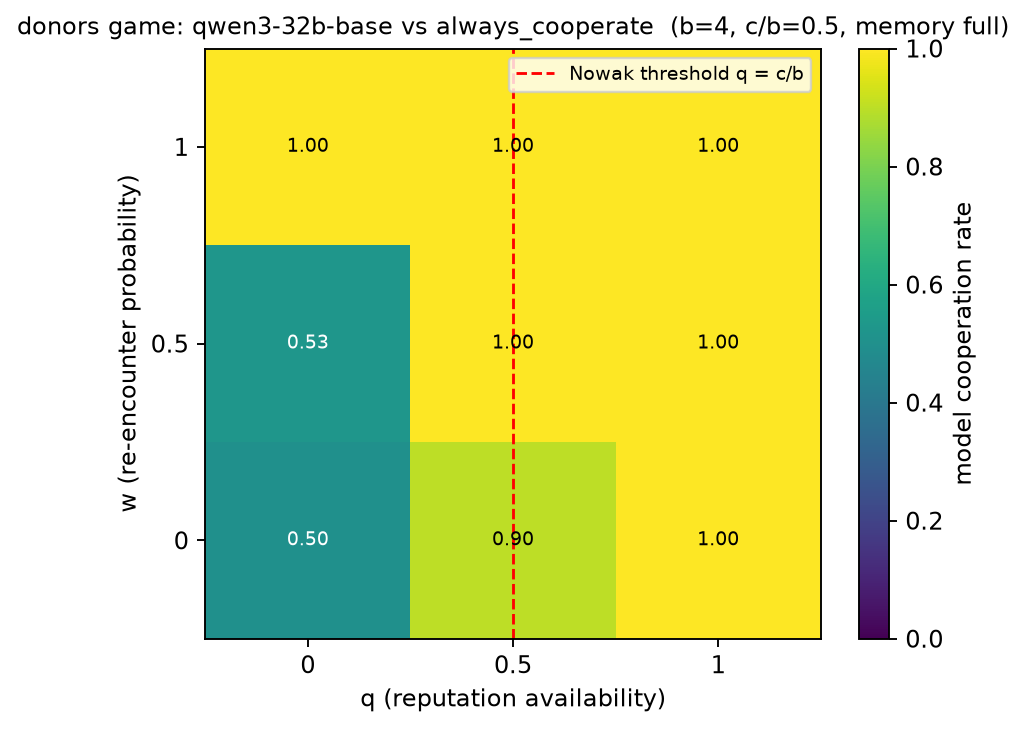

llm_dynamics/results/qwen32b_base_donors_v2/always_cooperate/heatmap_qwen3-32b-base_always_cooperate_m1.png


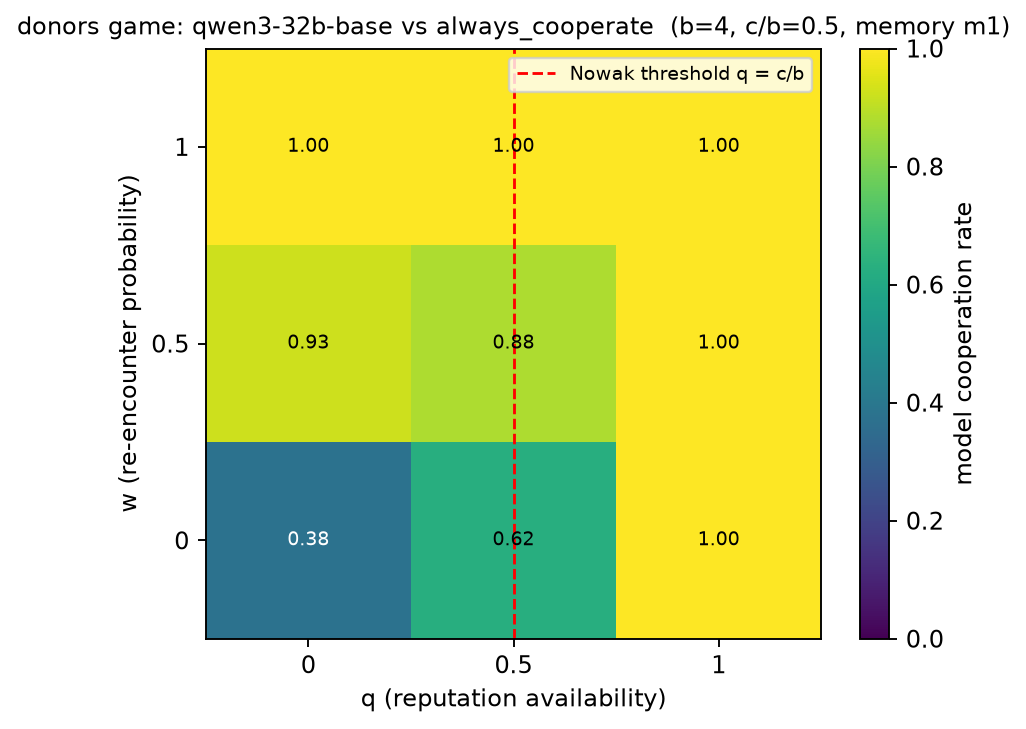

llm_dynamics/results/qwen32b_base_donors_v2/always_cooperate/heatmap_qwen3-32b-base_always_cooperate_m2.png


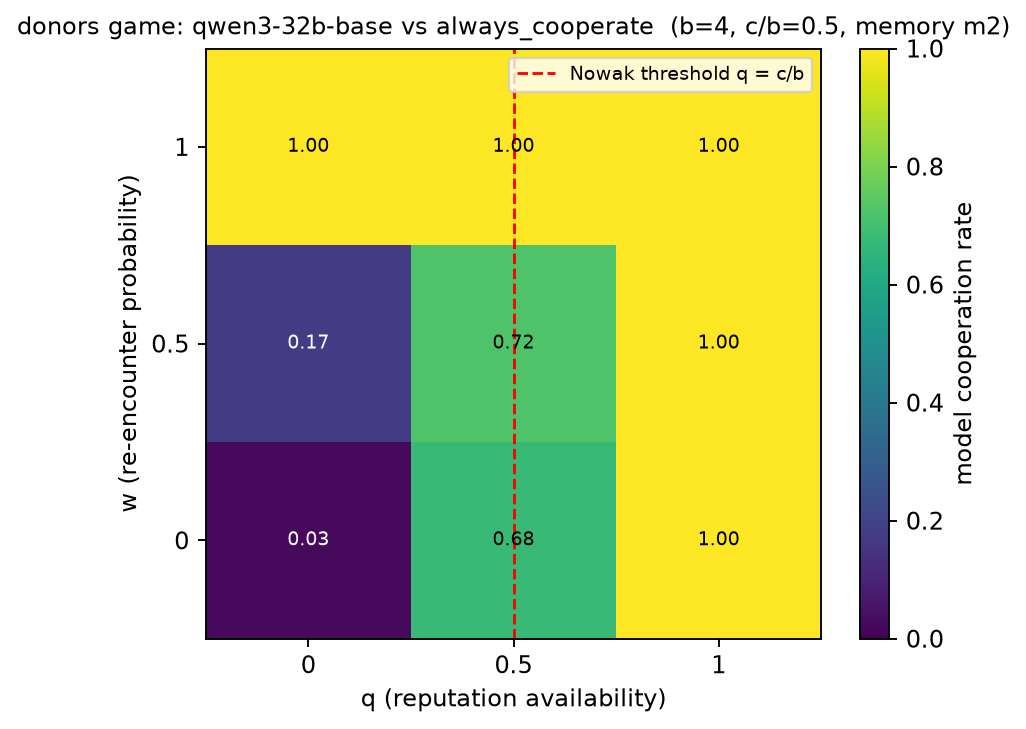

llm_dynamics/results/qwen32b_base_donors_v2/always_cooperate/heatmap_qwen3-32b-base_always_cooperate_m4.png


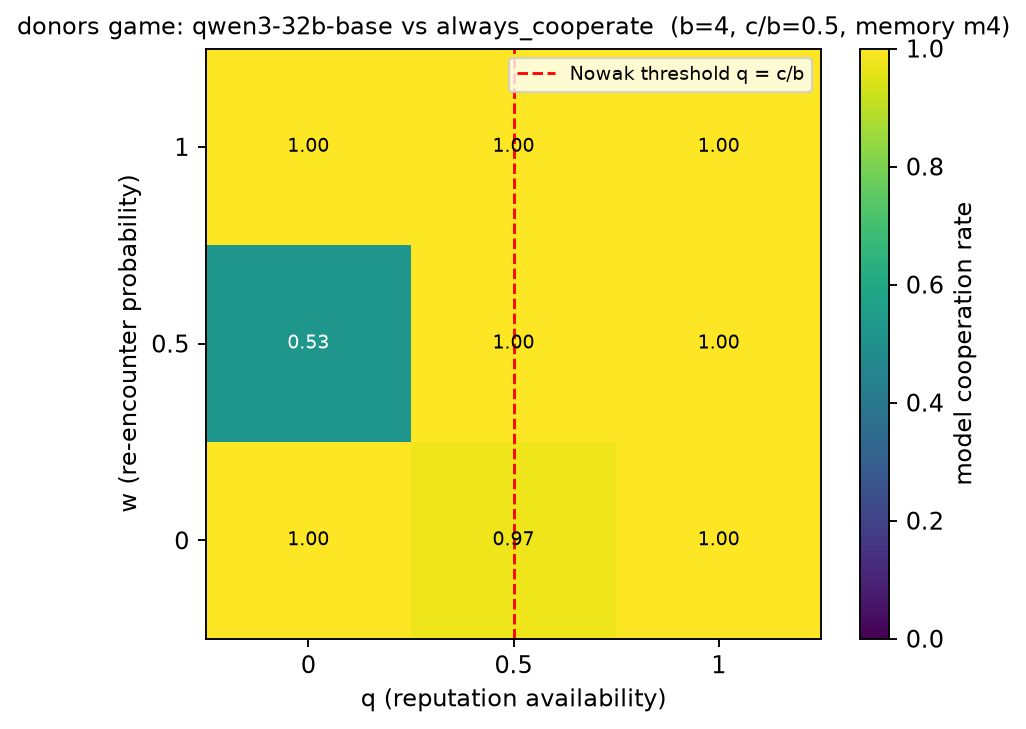

llm_dynamics/results/qwen32b_base_donors_v2/always_defect/heatmap_qwen3-32b-base_always_defect_full.png


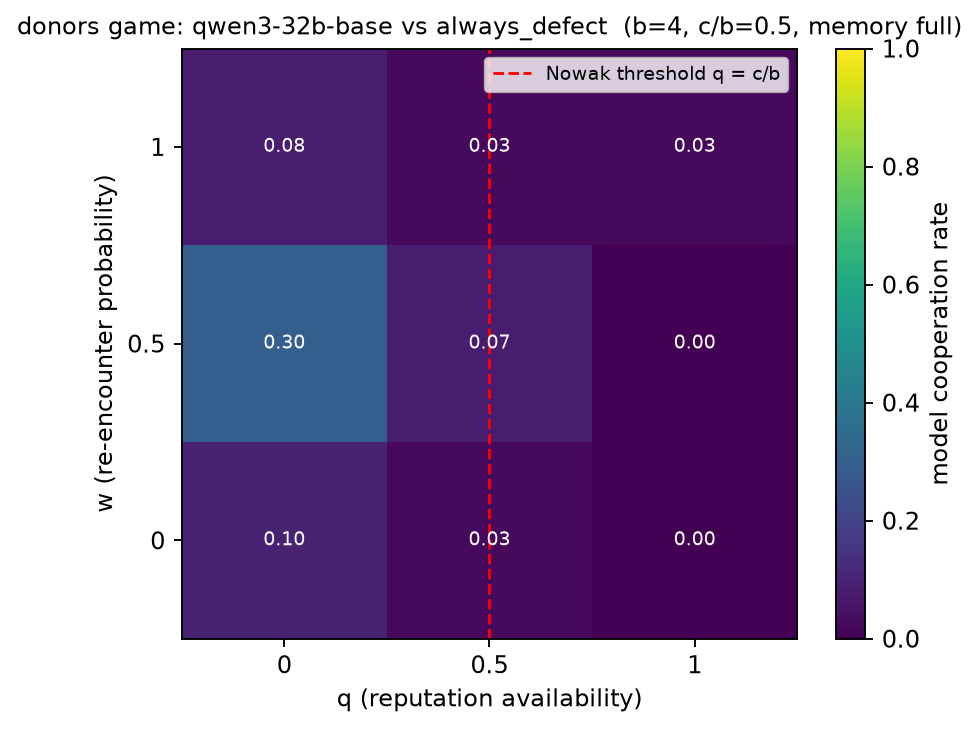

llm_dynamics/results/qwen32b_base_donors_v2/always_defect/heatmap_qwen3-32b-base_always_defect_m1.png


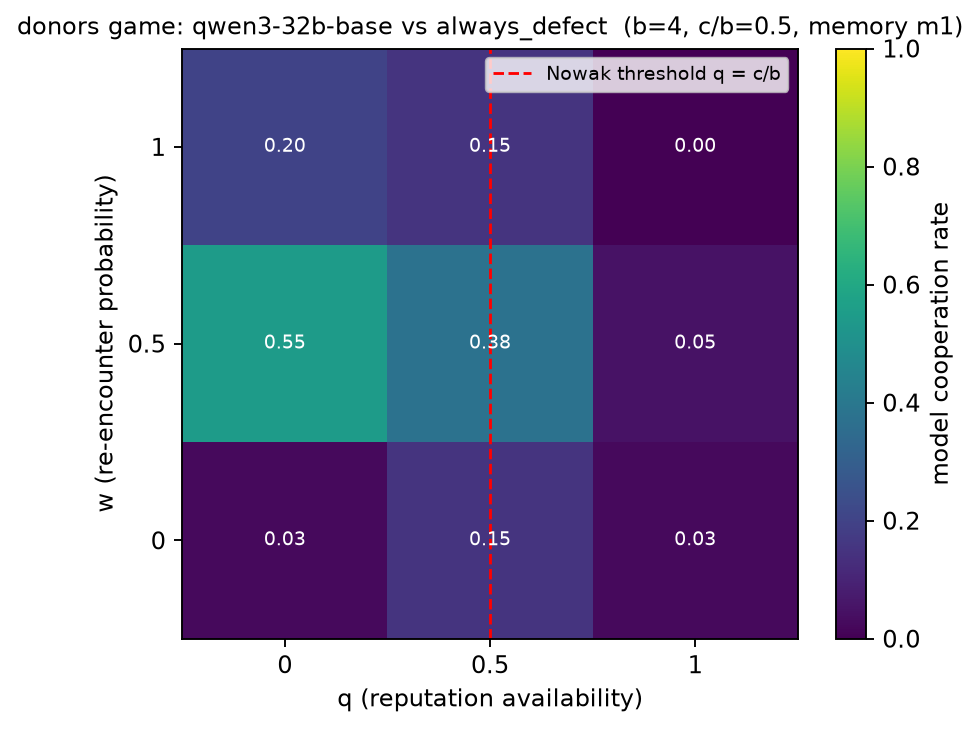

llm_dynamics/results/qwen32b_base_donors_v2/always_defect/heatmap_qwen3-32b-base_always_defect_m2.png


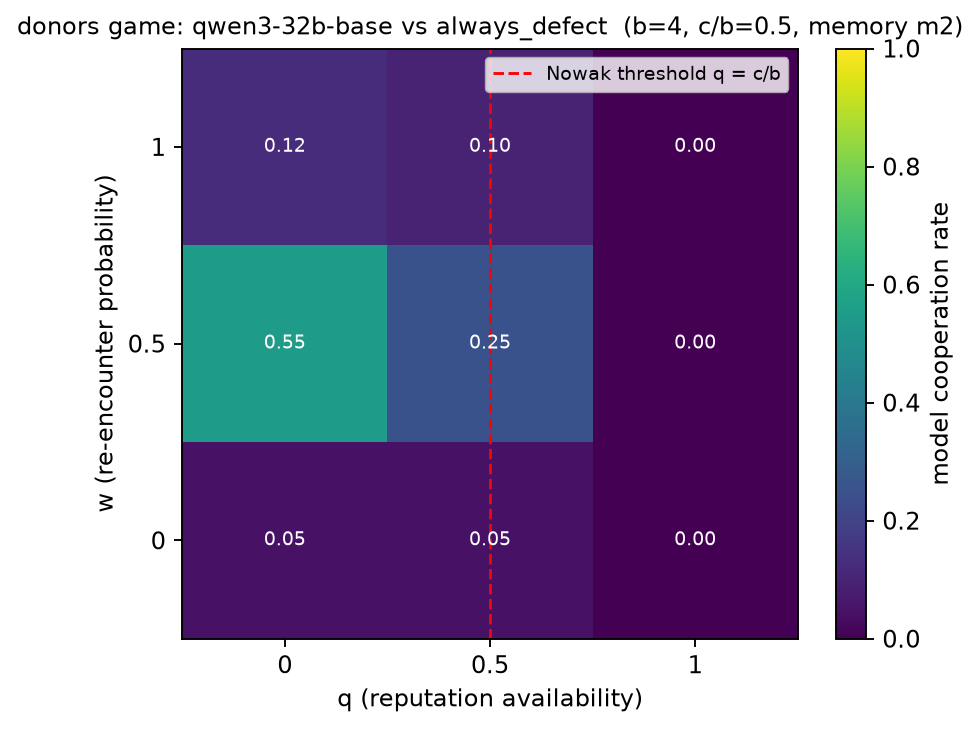

llm_dynamics/results/qwen32b_base_donors_v2/always_defect/heatmap_qwen3-32b-base_always_defect_m4.png


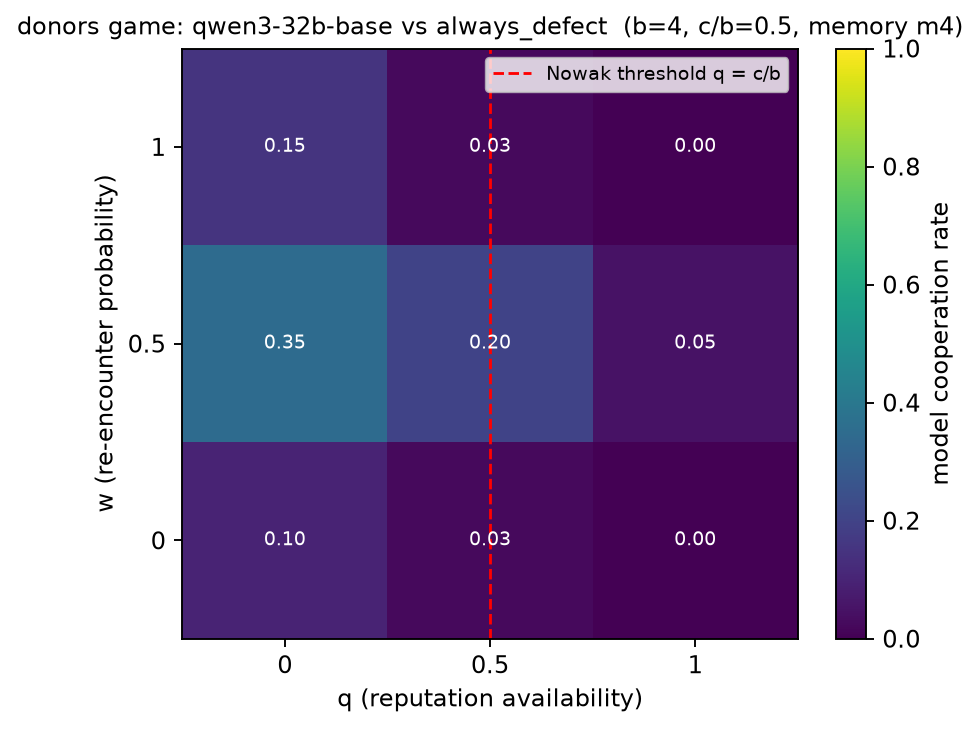

llm_dynamics/results/qwen32b_base_donors_v2/generous_tit_for_tat/heatmap_qwen3-32b-base_generous_tit_for_tat_full.png


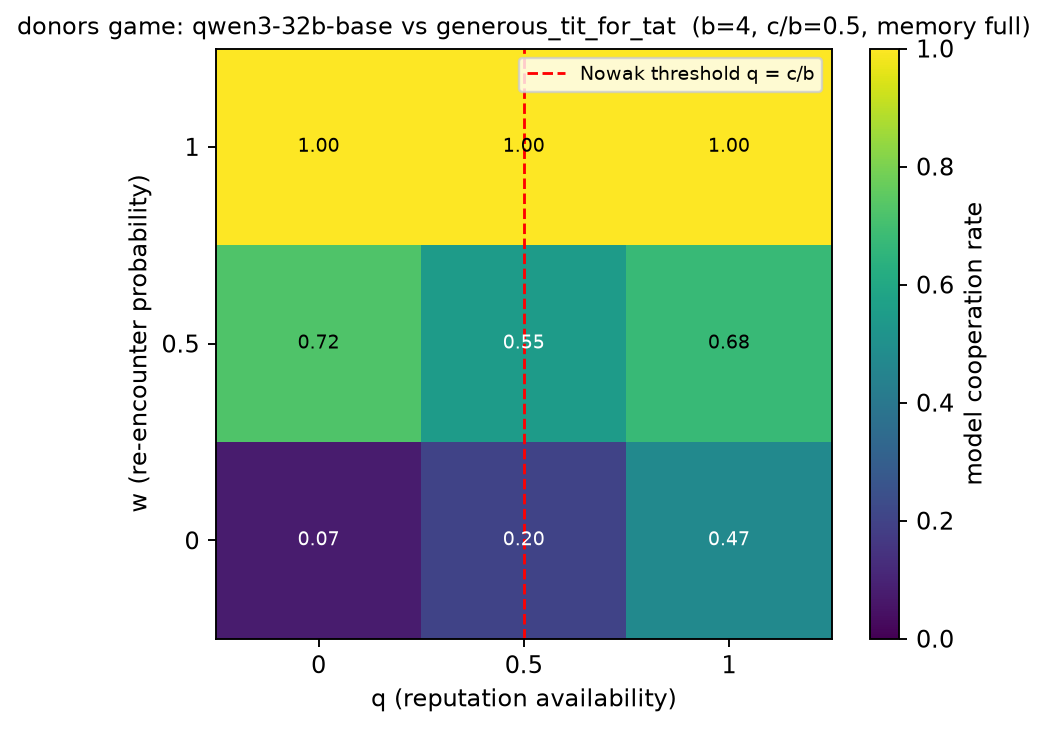

llm_dynamics/results/qwen32b_base_donors_v2/generous_tit_for_tat/heatmap_qwen3-32b-base_generous_tit_for_tat_m1.png


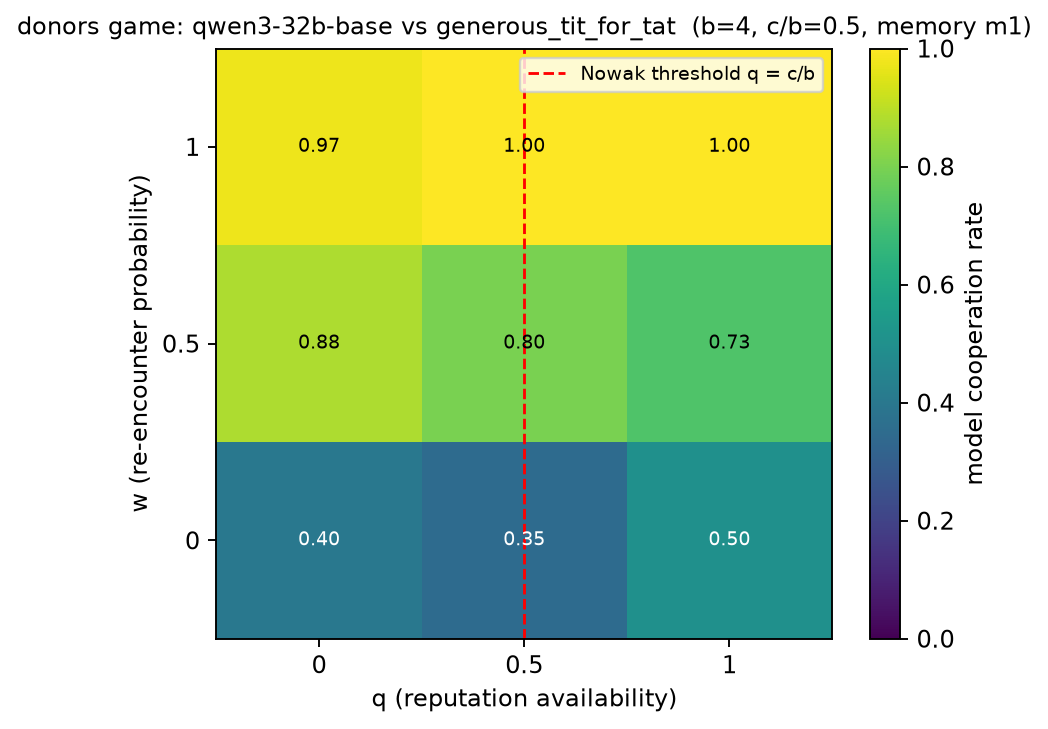

llm_dynamics/results/qwen32b_base_donors_v2/generous_tit_for_tat/heatmap_qwen3-32b-base_generous_tit_for_tat_m2.png


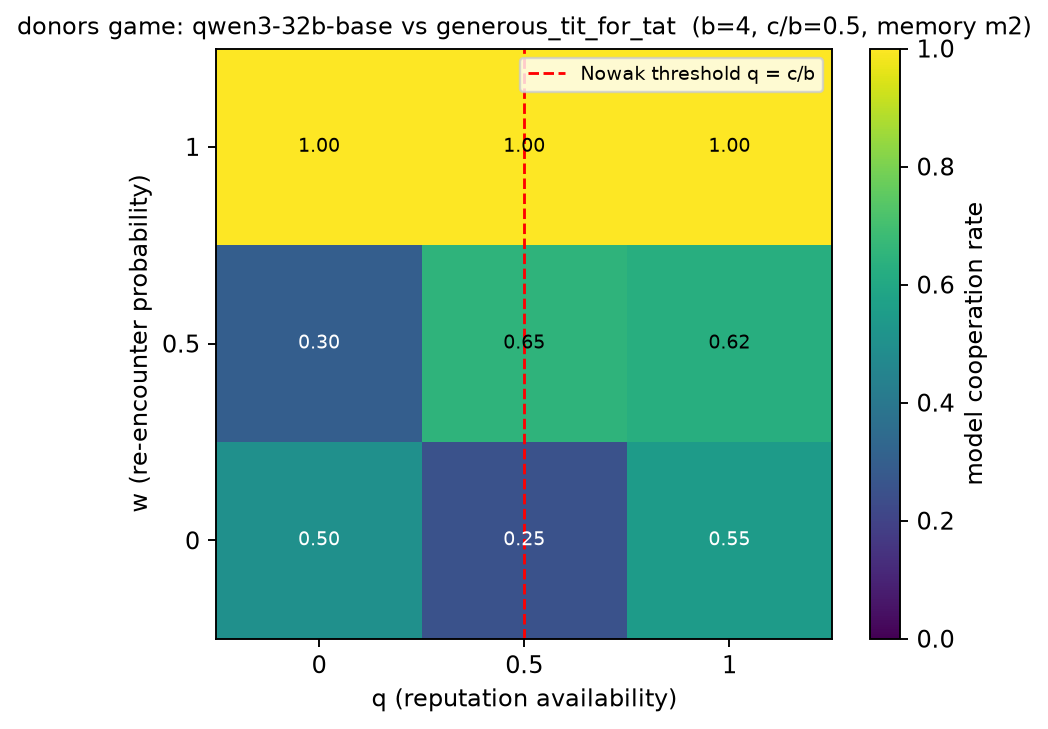

llm_dynamics/results/qwen32b_base_donors_v2/generous_tit_for_tat/heatmap_qwen3-32b-base_generous_tit_for_tat_m4.png


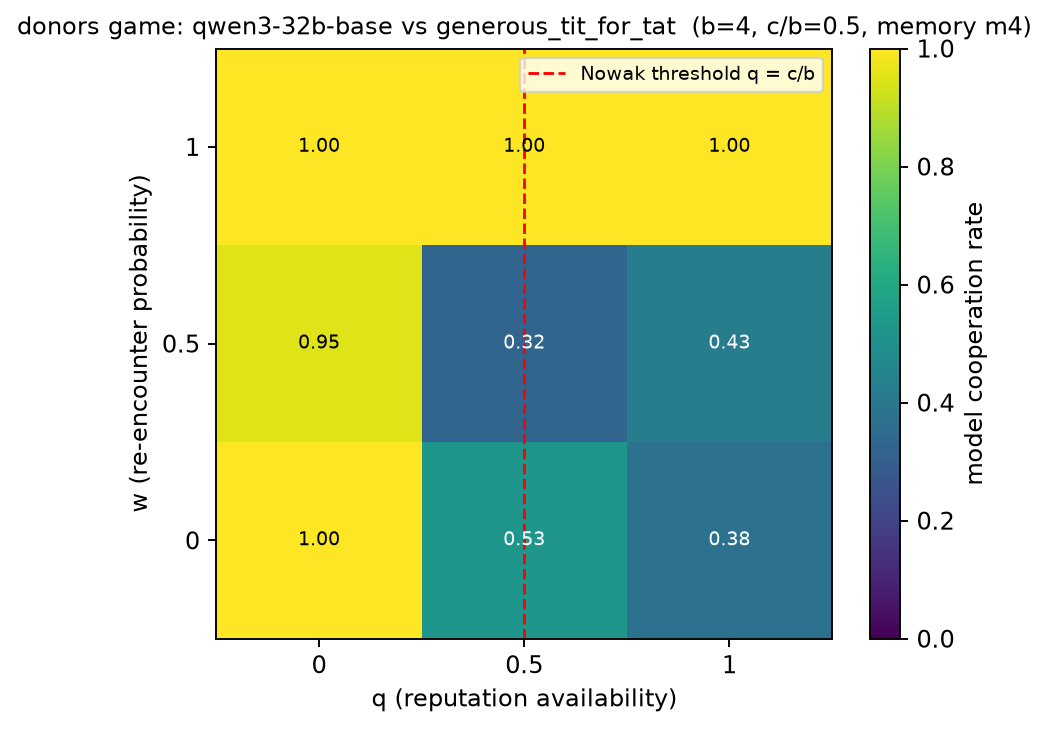

llm_dynamics/results/qwen32b_base_donors_v2/grim_trigger/heatmap_qwen3-32b-base_grim_trigger_full.png


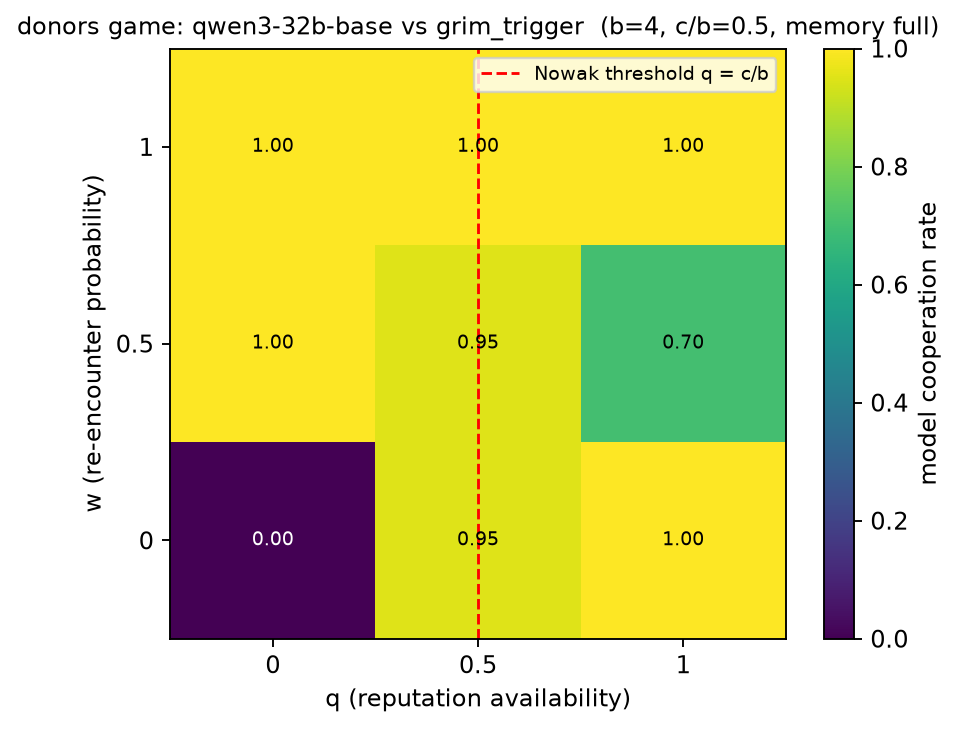

llm_dynamics/results/qwen32b_base_donors_v2/grim_trigger/heatmap_qwen3-32b-base_grim_trigger_m1.png


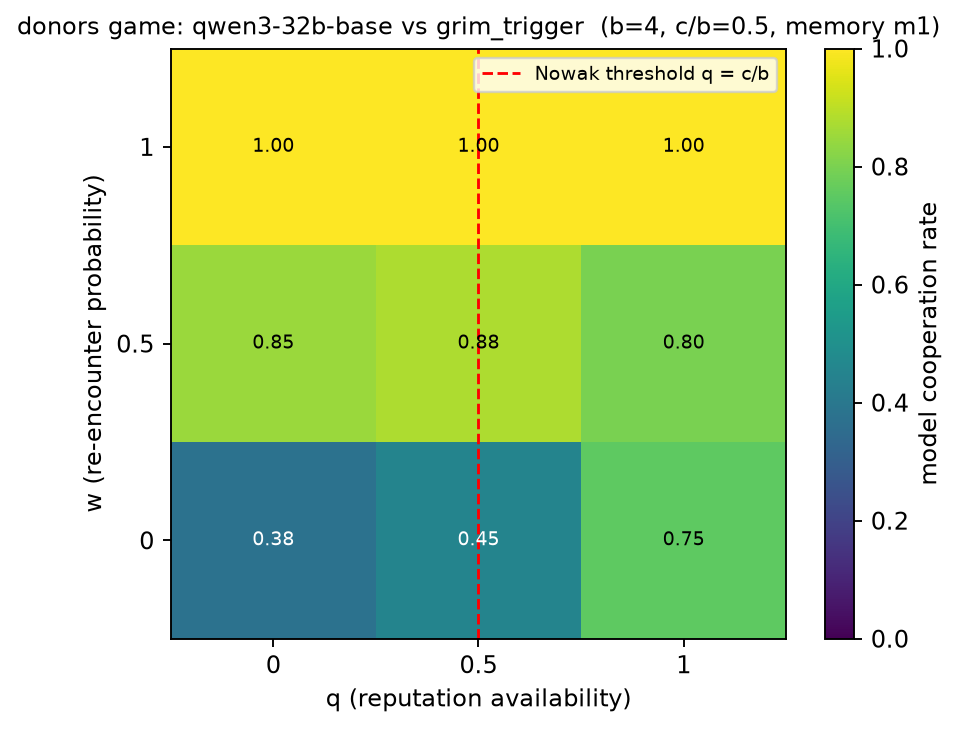

llm_dynamics/results/qwen32b_base_donors_v2/grim_trigger/heatmap_qwen3-32b-base_grim_trigger_m2.png


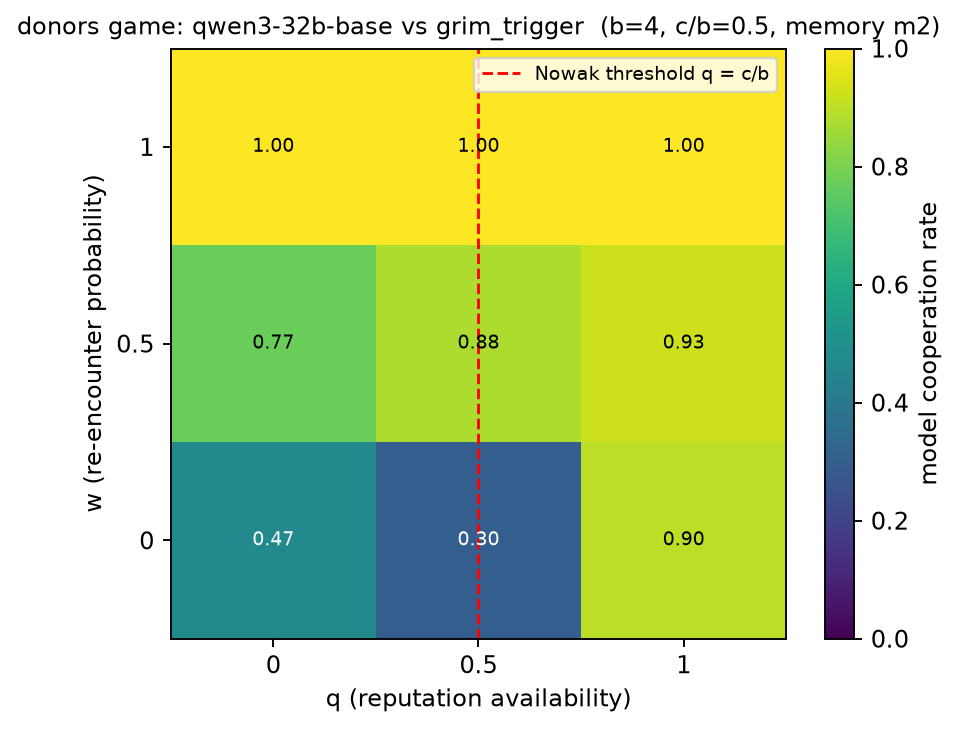

llm_dynamics/results/qwen32b_base_donors_v2/grim_trigger/heatmap_qwen3-32b-base_grim_trigger_m4.png


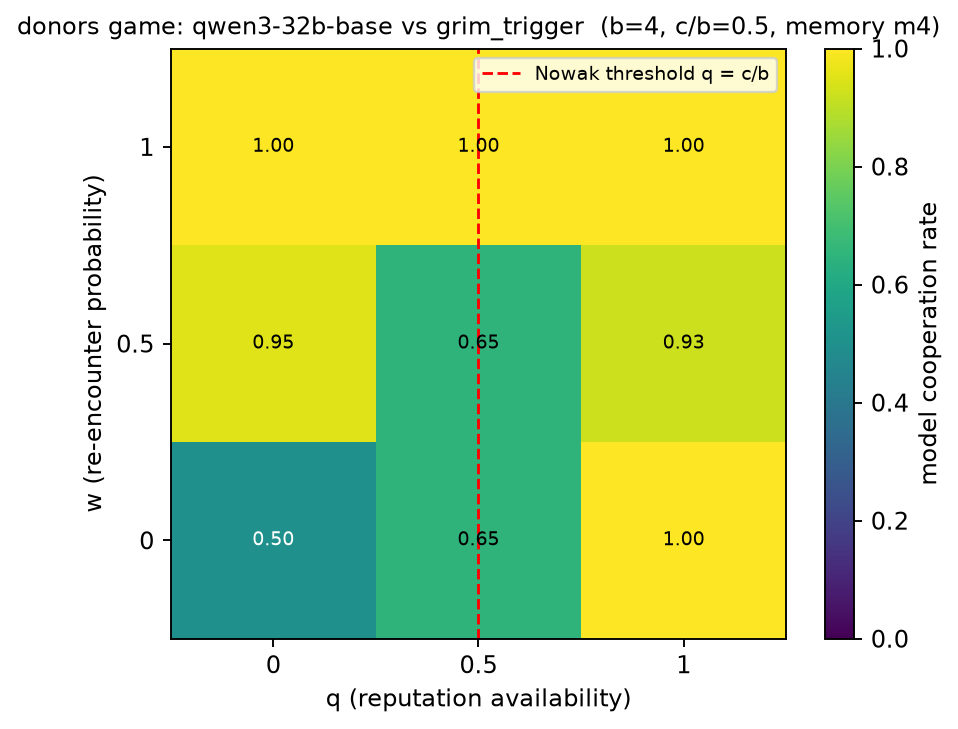

llm_dynamics/results/qwen32b_base_donors_v2/random/heatmap_qwen3-32b-base_random_full.png


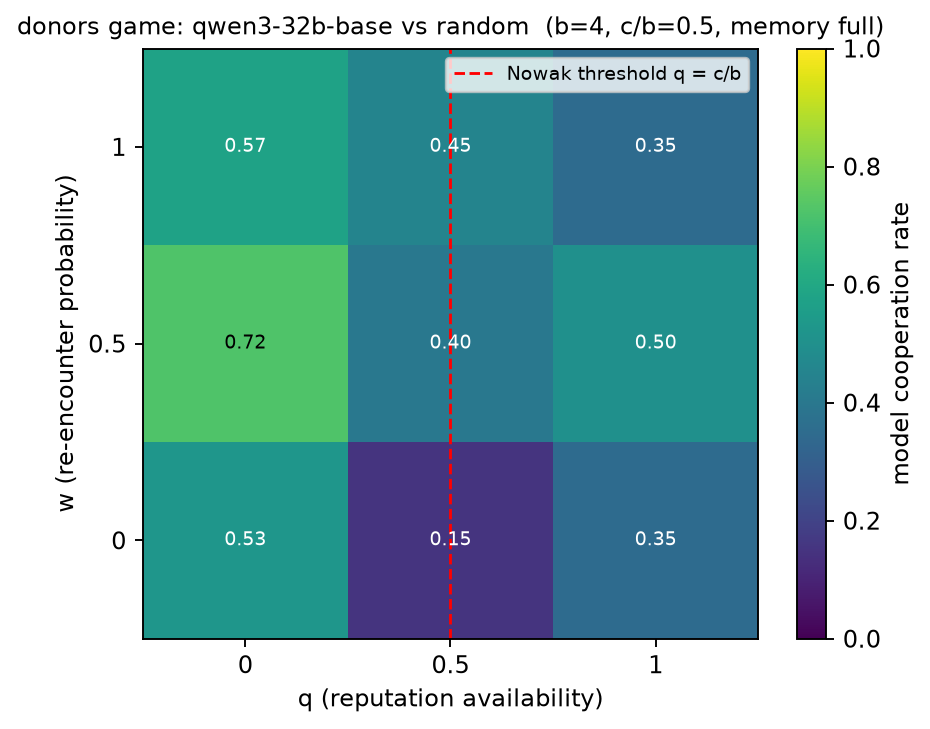

llm_dynamics/results/qwen32b_base_donors_v2/random/heatmap_qwen3-32b-base_random_m1.png


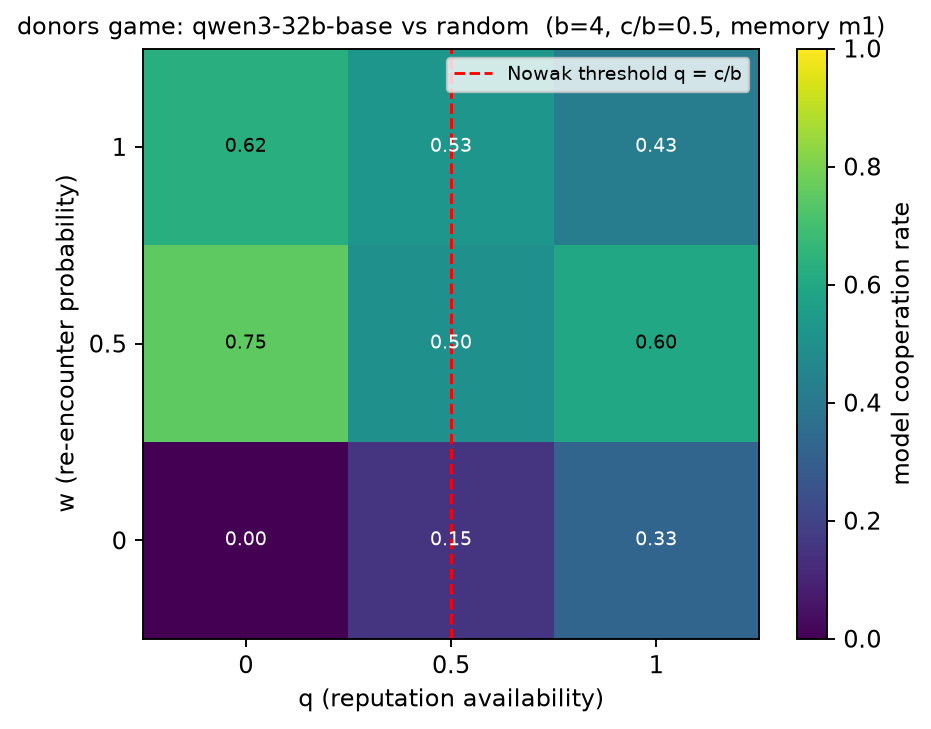

llm_dynamics/results/qwen32b_base_donors_v2/random/heatmap_qwen3-32b-base_random_m2.png


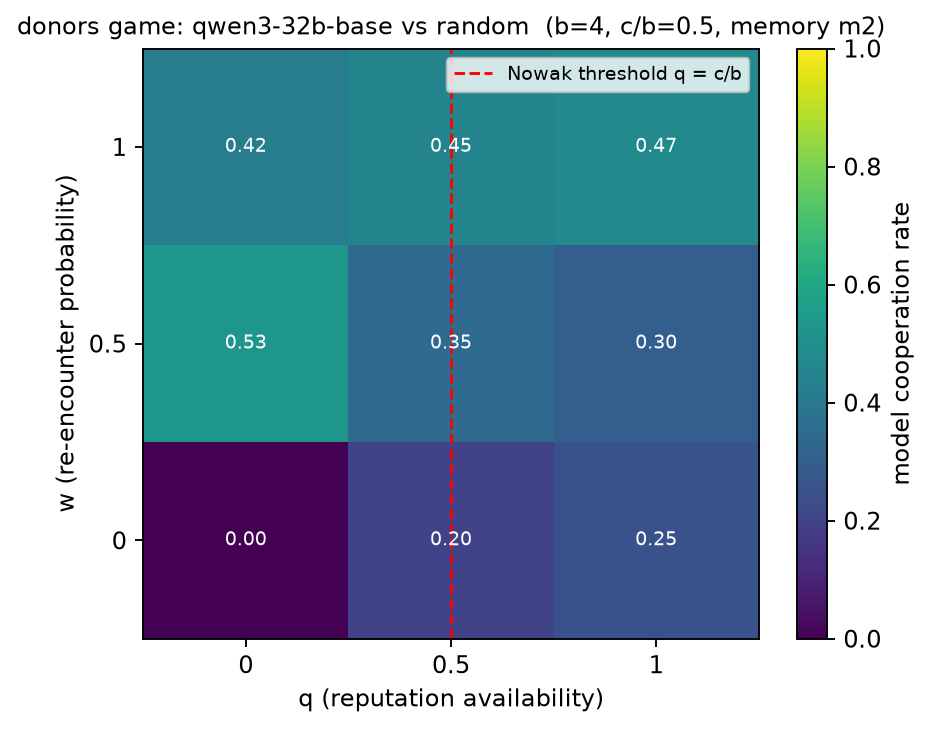

llm_dynamics/results/qwen32b_base_donors_v2/random/heatmap_qwen3-32b-base_random_m4.png


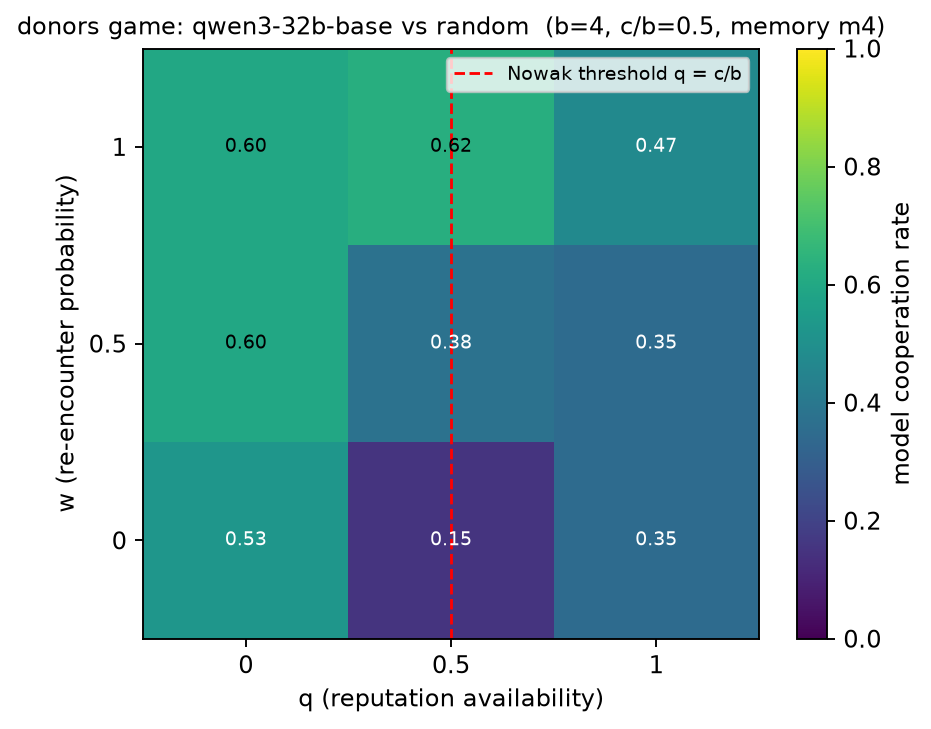

llm_dynamics/results/qwen32b_base_donors_v2/suspicious_tit_for_tat/heatmap_qwen3-32b-base_suspicious_tit_for_tat_full.png


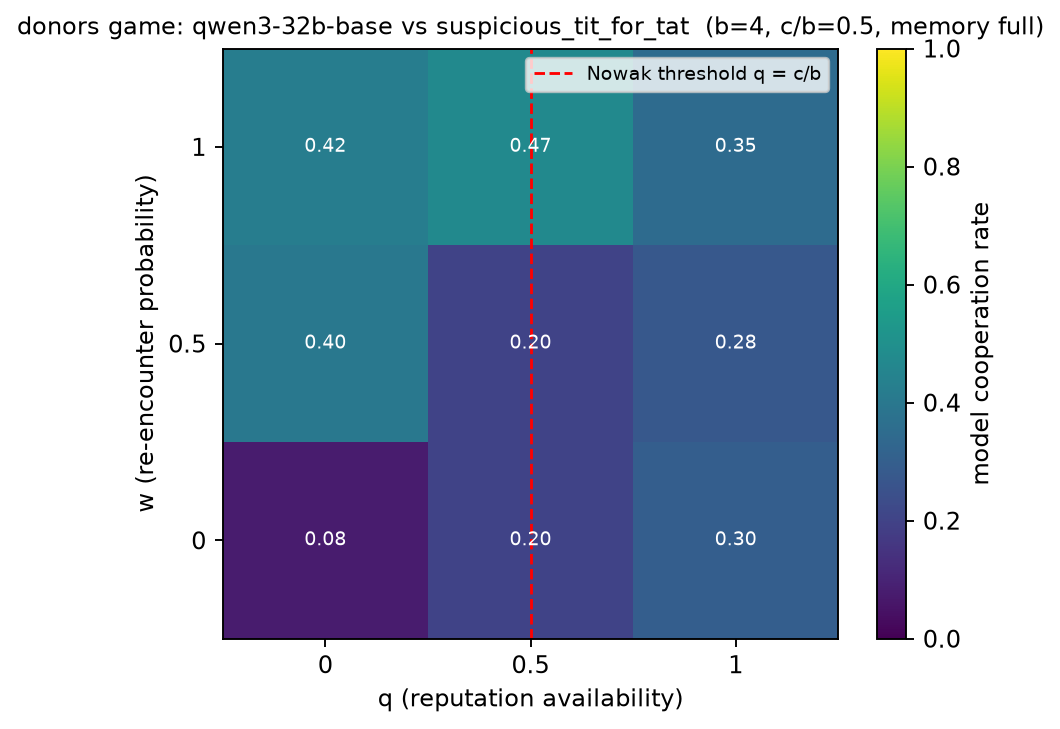

llm_dynamics/results/qwen32b_base_donors_v2/suspicious_tit_for_tat/heatmap_qwen3-32b-base_suspicious_tit_for_tat_m1.png


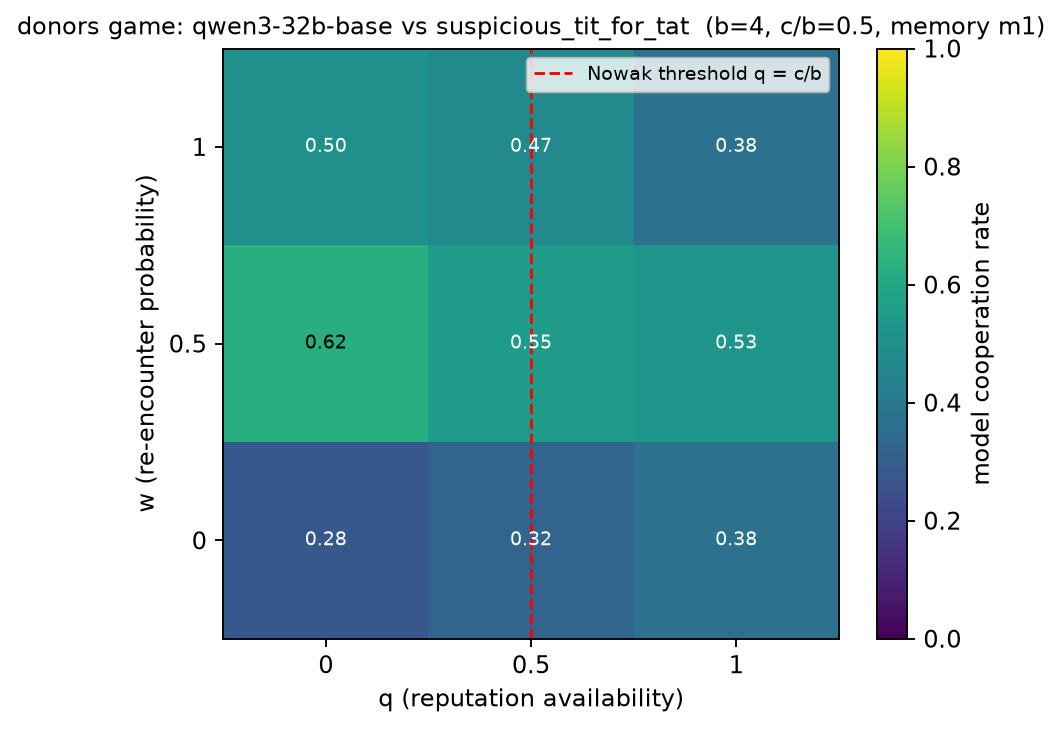

llm_dynamics/results/qwen32b_base_donors_v2/suspicious_tit_for_tat/heatmap_qwen3-32b-base_suspicious_tit_for_tat_m2.png


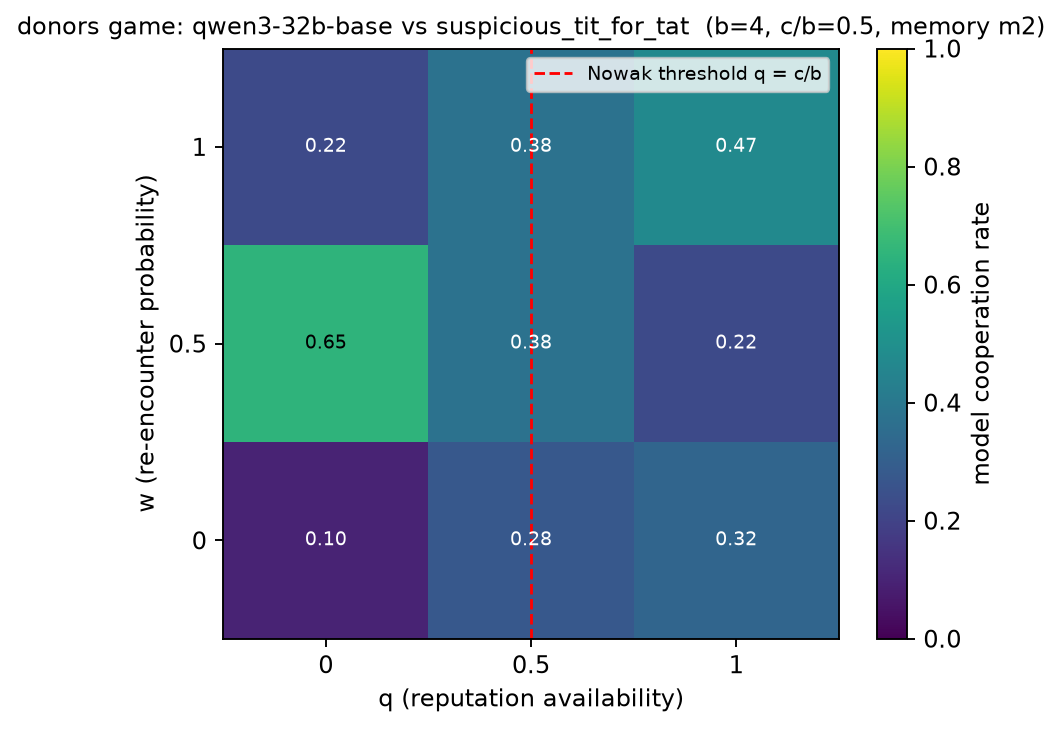

llm_dynamics/results/qwen32b_base_donors_v2/suspicious_tit_for_tat/heatmap_qwen3-32b-base_suspicious_tit_for_tat_m4.png


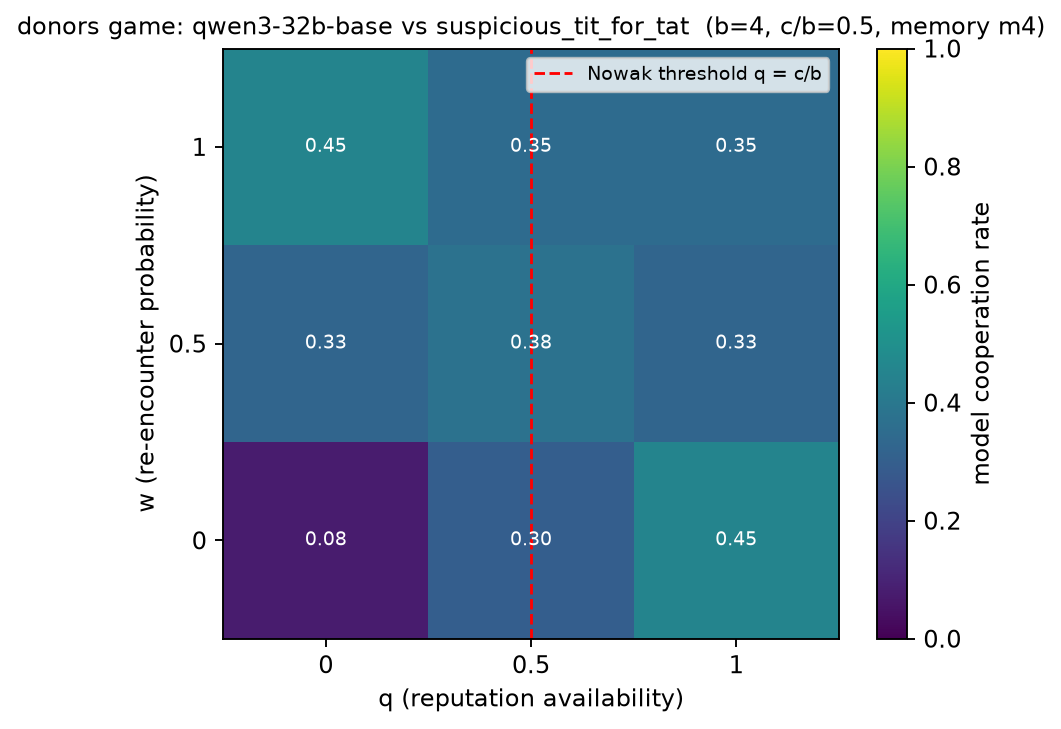

llm_dynamics/results/qwen32b_base_donors_v2/tit_for_tat/heatmap_qwen3-32b-base_tit_for_tat_full.png


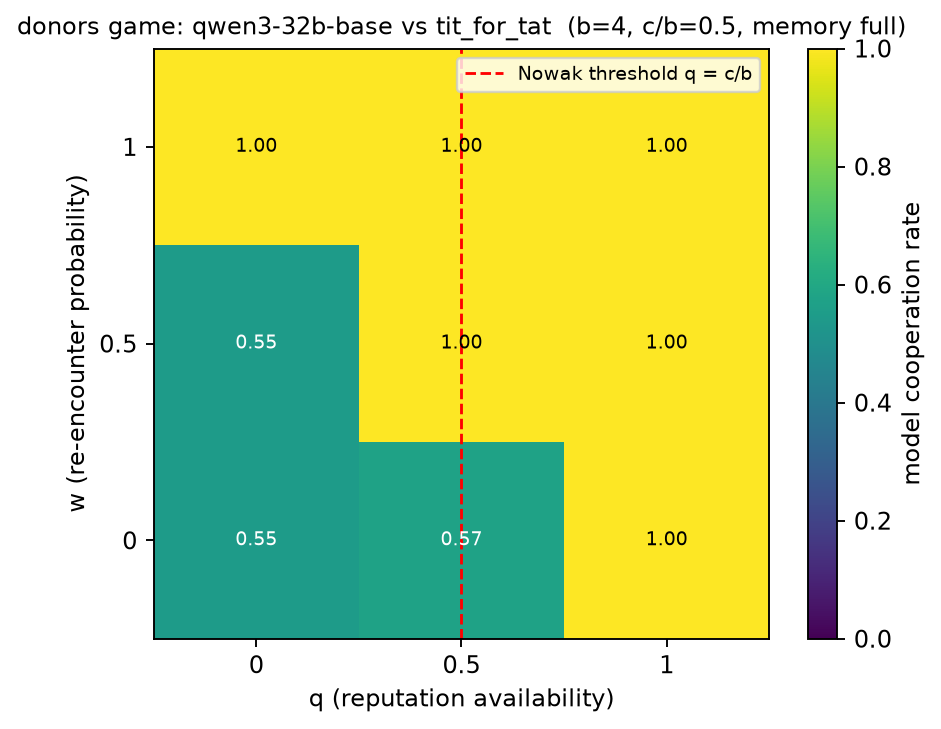

llm_dynamics/results/qwen32b_base_donors_v2/tit_for_tat/heatmap_qwen3-32b-base_tit_for_tat_m1.png


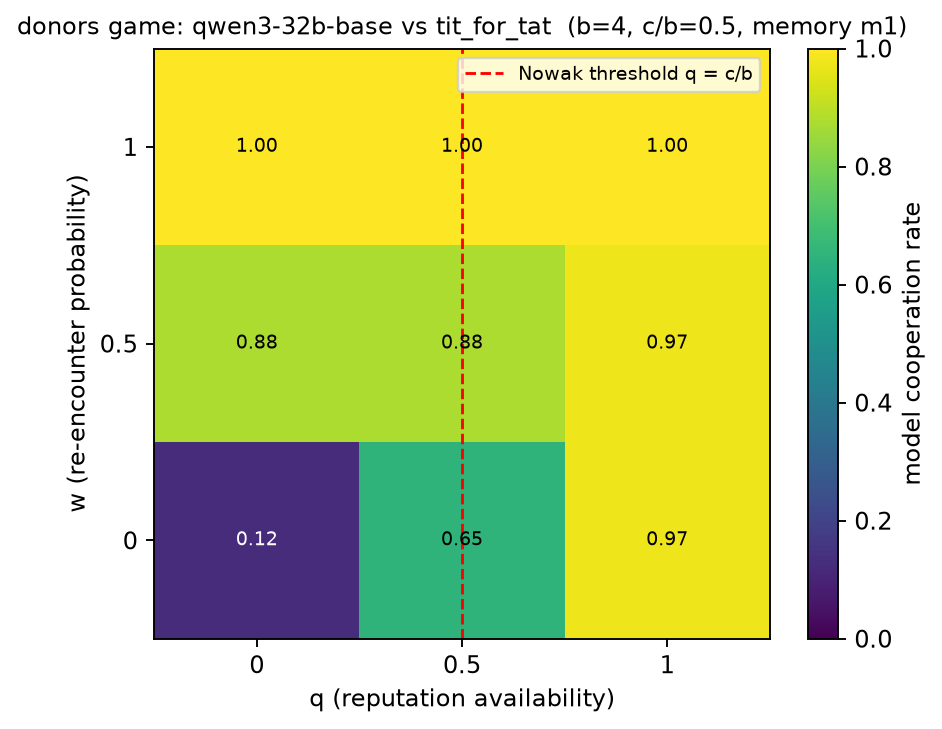

llm_dynamics/results/qwen32b_base_donors_v2/tit_for_tat/heatmap_qwen3-32b-base_tit_for_tat_m2.png


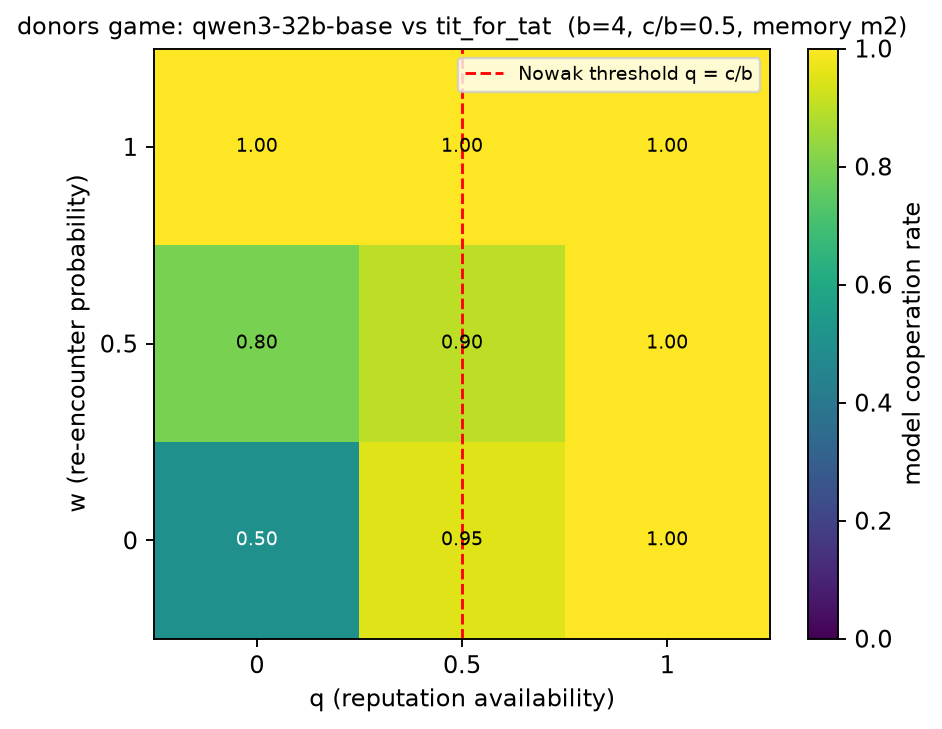

llm_dynamics/results/qwen32b_base_donors_v2/tit_for_tat/heatmap_qwen3-32b-base_tit_for_tat_m4.png


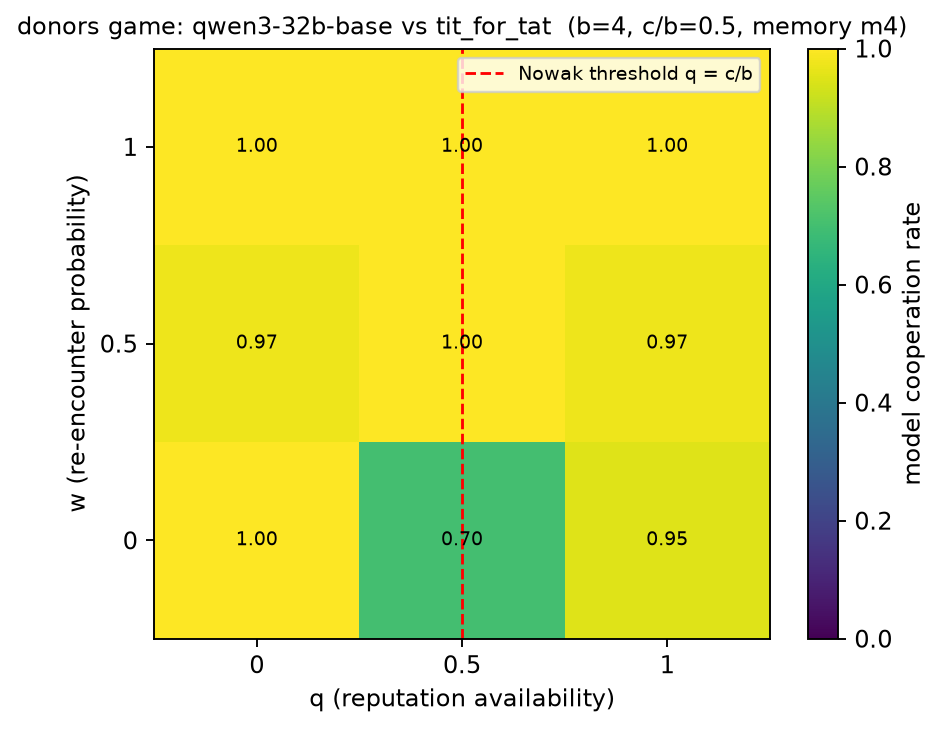

llm_dynamics/results/qwen32b_base_donors_v2/tit_for_two_tats/heatmap_qwen3-32b-base_tit_for_two_tats_full.png


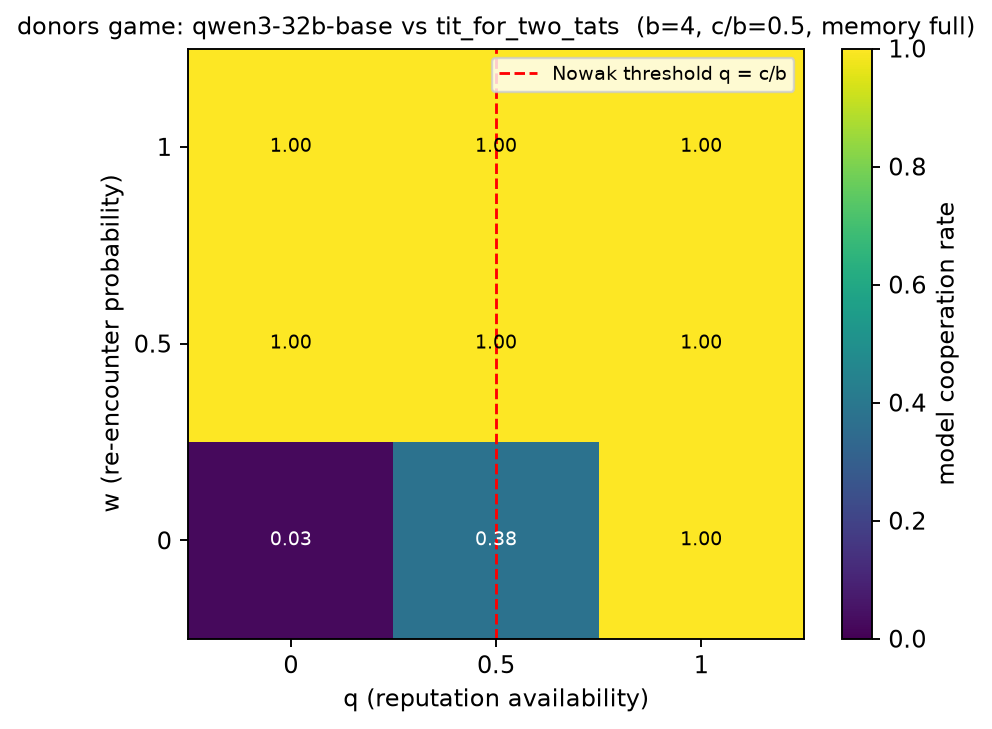

llm_dynamics/results/qwen32b_base_donors_v2/tit_for_two_tats/heatmap_qwen3-32b-base_tit_for_two_tats_m1.png


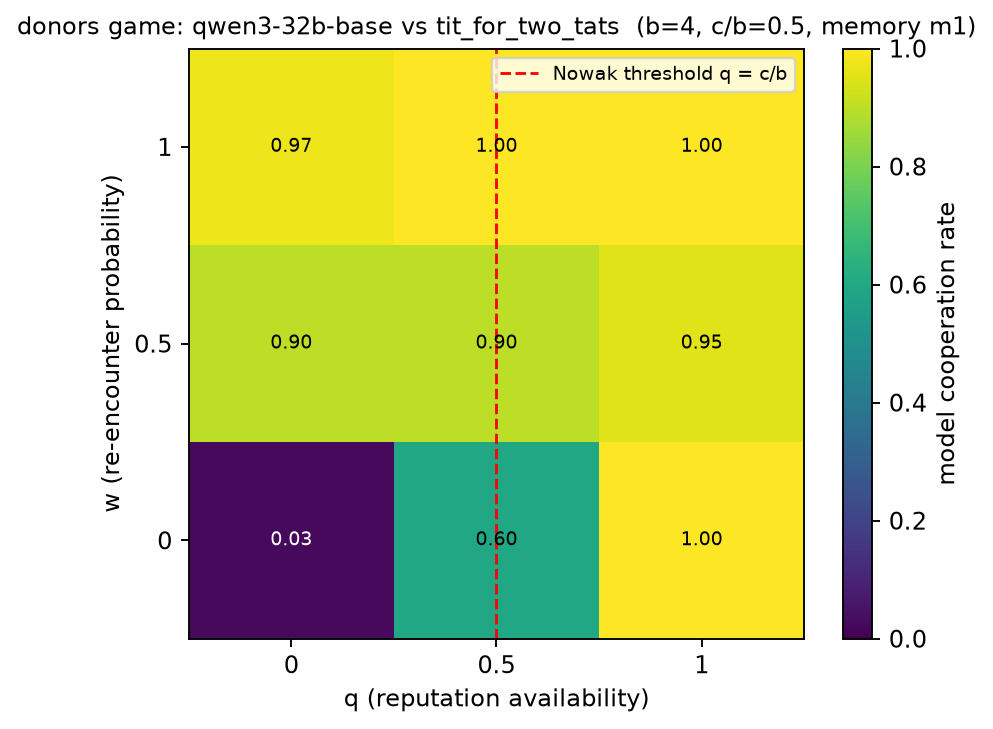

llm_dynamics/results/qwen32b_base_donors_v2/tit_for_two_tats/heatmap_qwen3-32b-base_tit_for_two_tats_m2.png


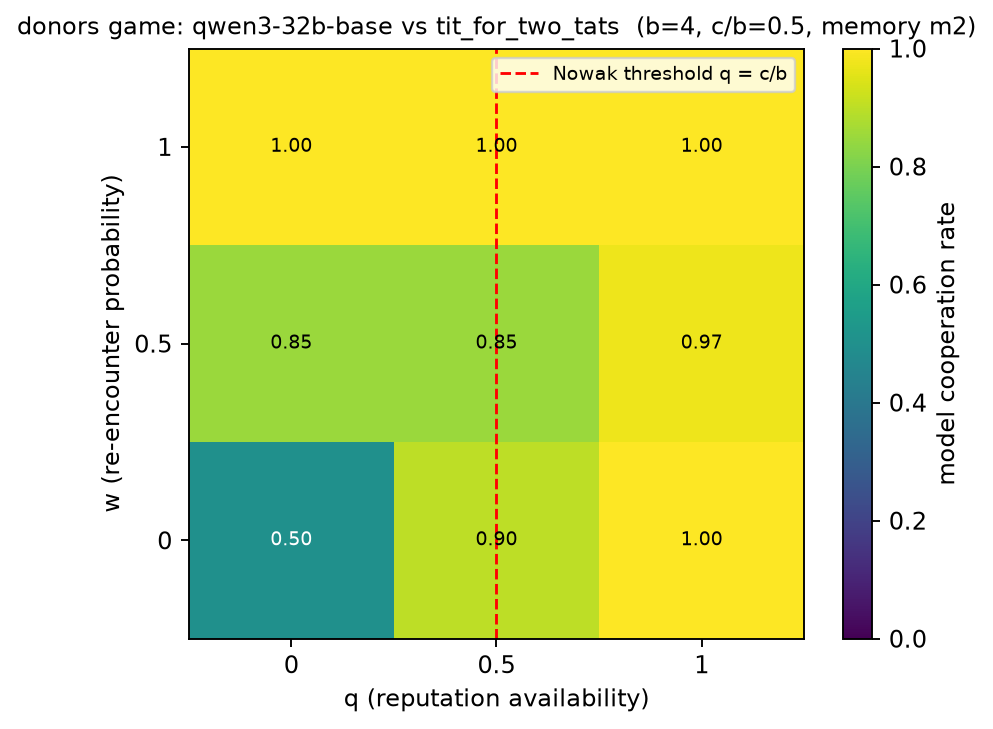

llm_dynamics/results/qwen32b_base_donors_v2/tit_for_two_tats/heatmap_qwen3-32b-base_tit_for_two_tats_m4.png


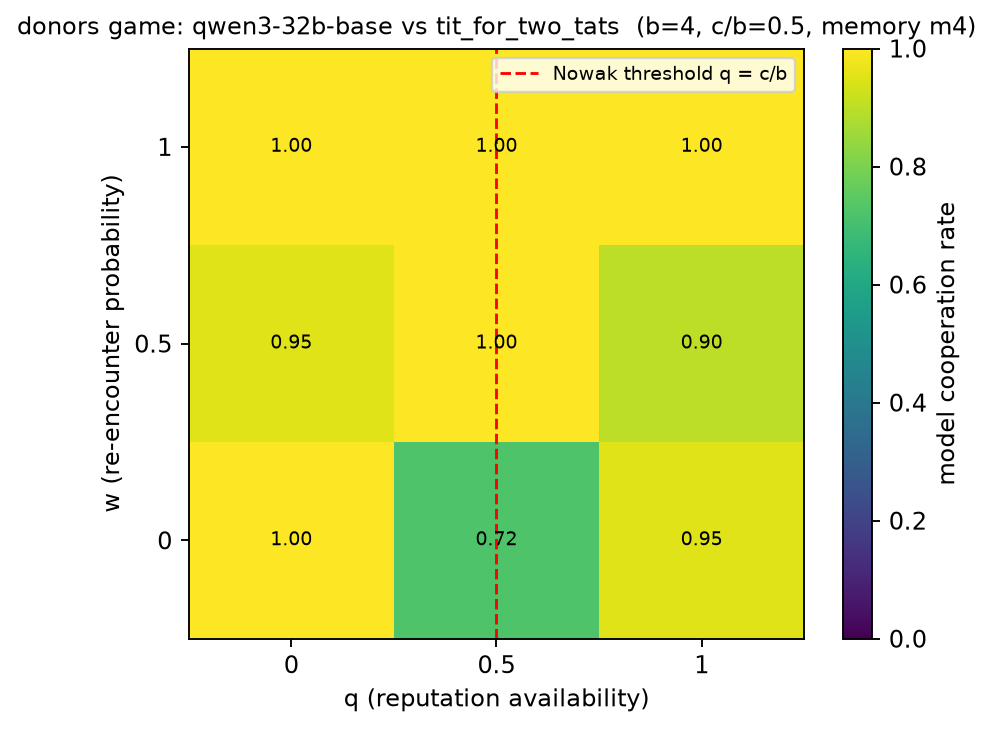

llm_dynamics/results/qwen32b_base_donors_v2/wsls/heatmap_qwen3-32b-base_wsls_full.png


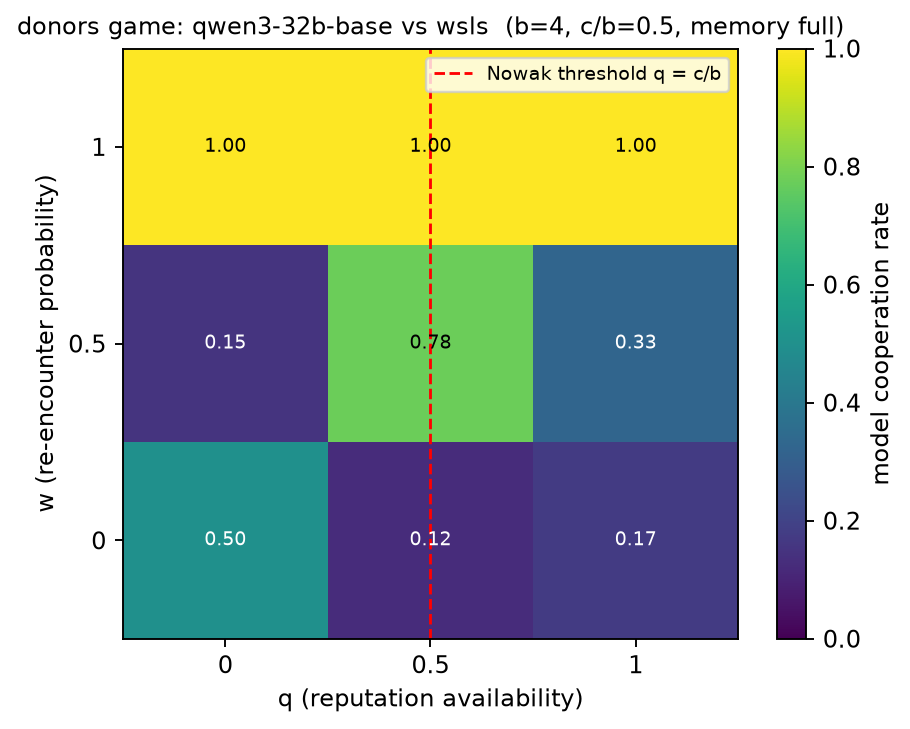

llm_dynamics/results/qwen32b_base_donors_v2/wsls/heatmap_qwen3-32b-base_wsls_m1.png


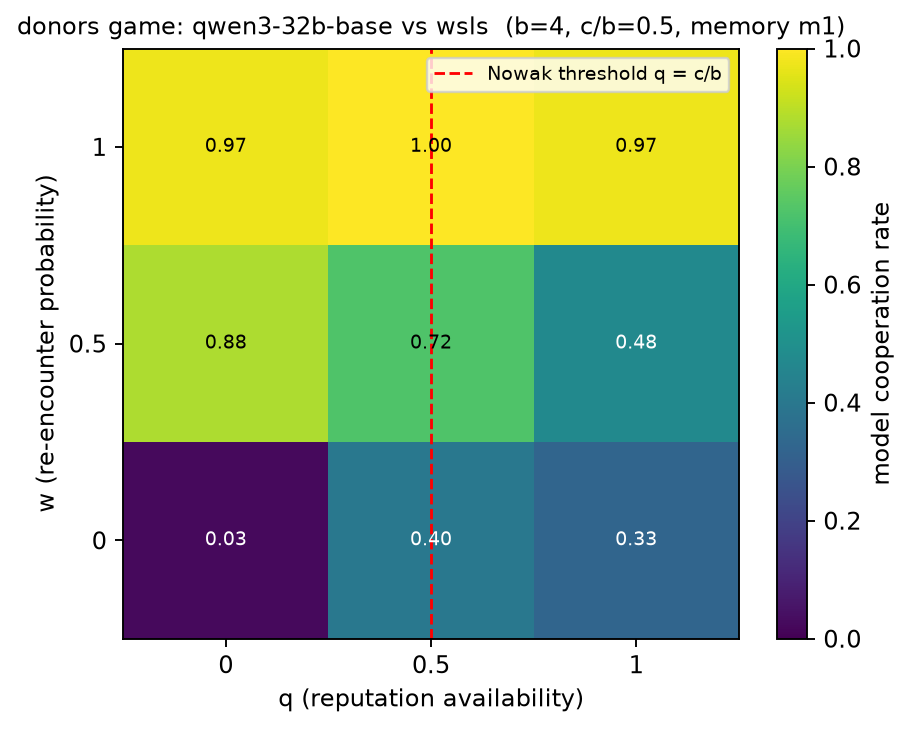

llm_dynamics/results/qwen32b_base_donors_v2/wsls/heatmap_qwen3-32b-base_wsls_m2.png


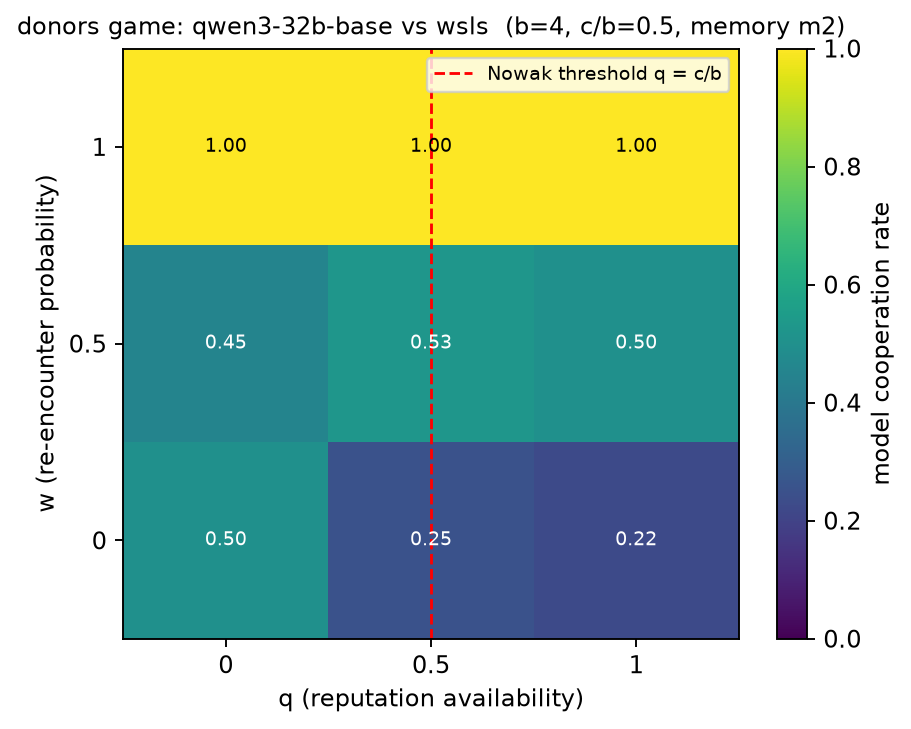

llm_dynamics/results/qwen32b_base_donors_v2/wsls/heatmap_qwen3-32b-base_wsls_m4.png


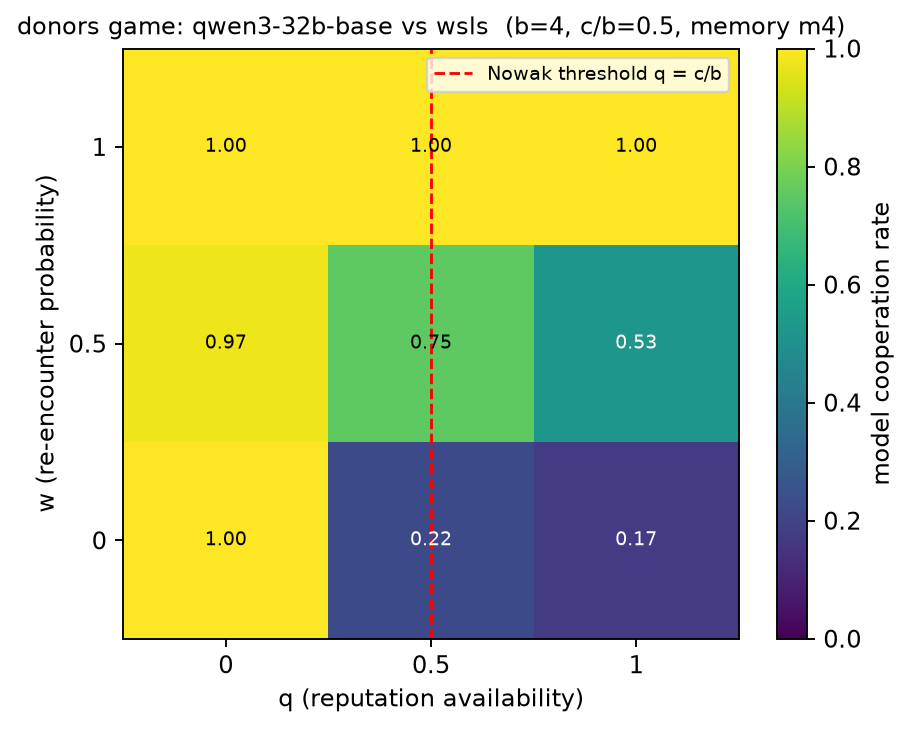

In [7]:
# v2 heatmaps per strategy x memory, when present
for f in sorted(glob.glob('llm_dynamics/results/qwen32b_base_donors_v2/*/heatmap_*.png')):
    print(f); _d(Image(f, width=420))

### 5.5 The arrow fields

The flow-field figures for every game and setting (CRLD theory fields, and
the measured LLM paths over them) live in a companion notebook so this one
stays light: **`llm_dynamics/llm_dynamics_flow_fields.ipynb`** (built by the
same script; figures from `python -m llm_dynamics.flow_grids`). One
representative field here — the four games at memory 2:

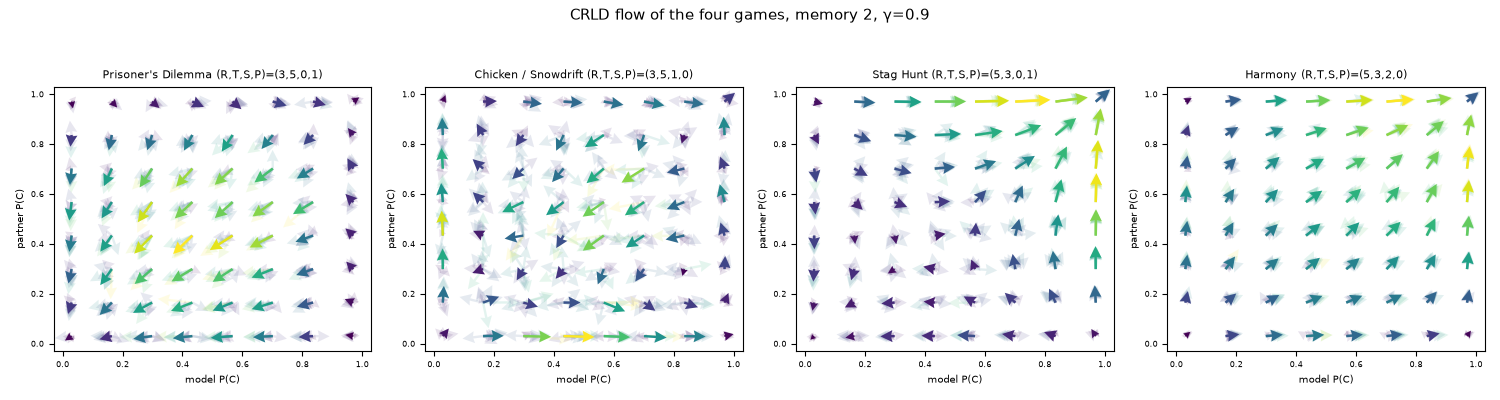

In [8]:
f = 'llm_dynamics/results/flow_grids/theory_matrix_m2.png'
if os.path.exists(f): _d(Image(f, width=900))

## 6. Findings so far (base model) and what to compare against

* **Base Qwen3-32B is a near-deterministic hard tit-for-tat** in the donors
  framing: $P(C\mid cc)=1$, $P(C\mid dc)=1$, $P(C\mid cd)=0$ at every $(w,q)$
  corner (memory 1). In the reciprocity plane it sits at the (1, 0) corner, where
  the fixed-opponent CRLD flow vs TFT points *away* (toward forgiveness).
* **$q$ acts through the reputation report, $w$ barely acts.** Opening $P(C)$
  vs AllD is 0.00 whenever a report is guaranteed ($q=1$) and 1.00 at $q=0,w\ge.5$;
  with one-shot strangers ($w=0$) and no information it hedges (0.50 vs AllC).
  After round 1 the last move dominates and $(w,q)$ stop mattering.
* **Optimality view:** best-response captured ≈1.0 vs AllD and vs TFT with a
  stable partner ($w=1$, 0.98); leaves a third on the table vs AllC (never
  exploits, 0.67) and vs one-shot strangers (cooperates where the oracle
  defects). Welfare captured is 1.00 vs TFT and AllC at $w=1$ (it reaches the
  Pareto-efficient mutual-cooperation point) and 0.67 vs AllD (it refuses to be
  exploited) — i.e. the base model is on the reciprocal, not the altruistic,
  side of that trade-off.
* **Memory matters exactly as in the paper:** PD vs TFT at memory 1 falls into
  the TFT echo cycle (coop 0.35, captured 0.69); memory 2 escapes (0.95 / 1.00).
* **Payoff-structure blindness:** the memory-1 probed policy is identical across
  PD, Chicken and Stag Hunt (`cc=1, cd=0, dc=1, dd=1`), and against AllD in
  Chicken/Harmony — where the best response is to *cooperate* — it retaliates
  and captures only 25–45%.

**For the RL-trained checkpoint** the cells to watch are: $P(C\mid cd)$
(forgiveness — does training move the star off the (1,0) corner?), the AllC
column (exploitation), the $w=0$ column (one-shot strangers), and the
Chicken/Harmony-vs-AllD cells (does it learn the game or stay a reflex
reciprocator?). Protocol: serve the merged checkpoint with
`serve_qwen32b.sbatch` (change model path / `--served-model-name`), then
`TAG=qwen32b_trained MODEL=<name> sbatch llm_dynamics/slurm/run_suite_v2.sbatch`,
then `reciprocity-figure --probes <base> <trained>`.

## 7. Caveats
* Two seeds per cell, 20 rounds: coarse; a $q=0$ column has identical prompts
  across partner rows, so differences there are sampling noise.
* $c/b=0.5$ fixed, so Nowak's thresholds sit on the middle grid value; a $c/b$
  sweep is needed to test threshold-tracking vs report-text-following.
* Probes are greedy at a fixed mid-game round; play is sampled across the whole
  game (end-game effects included).
* The played path in the reciprocity plane needs the `cd` state to occur; vs TFT
  it never does, so that coordinate stays at its 0.5 default (use the probe star).
* `grim_trigger` is pinned as its memory-$m$ truncation; suspicious TFT has the
  same state-space policy as TFT (the opening move is not a state).
